# DialectAI -- Region-Only, Flat Folder

## Структура датасета

```
recordings_wav/
    afrikaans1.wav       -> регион "afrikaans"
    afrikaans2.wav       -> регион "afrikaans"
    english1.wav         -> регион "english"
    moscow_001.wav       -> регион "moscow"   (формат с _ тоже работает)
    ...
```

Регион берётся из имени файла двумя способами:
- Если есть `_` -- часть до первого `_`: `moscow_001.wav` → `moscow`
- Если нет `_` -- все буквы до первой цифры: `afrikaans1.wav` → `afrikaans`

## Оптимизации (из v4)

| Nr    | Место         | Изменение                                        | Ускорение       |
|-------|---------------|--------------------------------------------------|-----------------|
| OPT-1 | HubertEncoder | Заморожено 21/24 трансформерных слоя             | 3-5x            |
| OPT-2 | DialectModel  | TDNN x 2 x 256 вместо Transformer 4L x 1024     | 8-12x           |
| OPT-3 | Trainer       | AMP autocast + GradScaler                        | 1.5-2x, -40%RAM |
| OPT-4 | DataLoader    | num_workers авто, pin_memory                     | 2-4x load       |
| OPT-5 | Dataset       | Кэш HuBERT на диск (один раз)                   | 5-20x           |

### Режимы
- **USE_CACHE=False** -- быстрый старт
- **USE_CACHE=True** -- максимальная скорость (кэш HuBERT)

In [18]:
%pip install "numpy==1.26.4" "torch==2.2.2" "torchaudio==2.2.2" "transformers==4.39.3" "librosa==0.10.2" "soundfile==0.12.1" "speechbrain==1.0.0" "scikit-learn==1.4.2" "pandas==2.2.2" "tqdm==4.66.4" "umap-learn==0.5.6" "hdbscan==0.8.38.post1" "matplotlib==3.8.4" "ipywidgets>=8.1" -q
print("Done. Restart kernel then run next cell.")

Note: you may need to restart the kernel to use updated packages.
Done. Restart kernel then run next cell.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: C:\Users\podgo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [19]:
# Imports
import os, math, random, pickle, hashlib, logging
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.cuda.amp import autocast, GradScaler

import librosa
import librosa.effects
import umap, hdbscan

from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score, f1_score, fbeta_score,
    roc_auc_score, cohen_kappa_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, log_loss,
    top_k_accuracy_score,
)
from transformers import AutoFeatureExtractor, HubertModel
try:
    from speechbrain.inference.speaker import EncoderClassifier
except ImportError:
    from speechbrain.pretrained import EncoderClassifier
from tqdm.notebook import tqdm

logging.basicConfig(level=logging.INFO, format="%(asctime)s  %(levelname)s  %(message)s", datefmt="%H:%M:%S")
log = logging.getLogger(__name__)

# === Константы ===
TARGET_SR        = 16_000
MAX_SEC          = 3
MAX_SAMPLES      = TARGET_SR * MAX_SEC
EMBED_DIM        = 1024
PROJ_DIM         = 256
EMB_DIM          = 128
BATCH_SIZE       = 16
EPOCHS           = 50
LR               = 3e-5
VAL_RATIO        = 0.15
PATIENCE         = 5
GRAD_CLIP        = 1.0
ARCFACE_M        = 0.5
ARCFACE_S        = 64.0
TRIPLET_M        = 0.5
UMAP_DIM_CLUSTER = 20
UMAP_DIM_VIZ     = 2
DATASET_ROOT     = "data_eng"   # плоская папка: dataset/region_NNN.wav

import sys as _sys
NUM_WORKERS = 0 if _sys.platform == "win32" else 4
USE_CACHE   = True
CACHE_DIR   = Path("runs/hubert_cache")
HUBERT_LOCAL_DIR = Path("runs/hubert_local")
HUBERT_FREEZE_LAYERS = 3

OUT_DIR = Path("runs/dialect_v5")
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
log.info("Device: %s | AMP: %s", device, torch.cuda.is_available())
print("OK | device:", device)

22:40:09  INFO  Device: cpu | AMP: False


OK | device: cpu


In [20]:
# 1. Audio loading [OPT-7] random crop при обучении
def load_audio(path: str, random_crop: bool = False) -> np.ndarray:
    audio, _ = librosa.load(path, sr=TARGET_SR, mono=True)
    audio, _ = librosa.effects.trim(audio, top_db=25)
    if len(audio) > MAX_SAMPLES:
        if random_crop:
            start = random.randint(0, len(audio) - MAX_SAMPLES)
            audio = audio[start: start + MAX_SAMPLES]
        else:
            audio = audio[:MAX_SAMPLES]
    if len(audio) < MAX_SAMPLES:
        audio = np.pad(audio, (0, MAX_SAMPLES - len(audio)), mode="constant")
    peak = np.max(np.abs(audio))
    if peak > 0:
        audio = audio / peak
    return audio.astype(np.float32)

In [21]:
# 2. SpeakerNormalizer [BUG-01 FIX] -- теперь работает с 256-dim (после проекции)
class SpeakerNormalizer(nn.Module):
    def __init__(self, hidden_dim: int = PROJ_DIM):
        super().__init__()
        self.inst_norm = nn.InstanceNorm1d(hidden_dim, affine=True, eps=1e-6)
        self.spk_proj  = nn.Linear(192, hidden_dim, bias=False)
        nn.init.zeros_(self.spk_proj.weight)

    def forward(self, hidden: torch.Tensor, spk_emb: Optional[torch.Tensor] = None) -> torch.Tensor:
        x = self.inst_norm(hidden.transpose(1, 2)).transpose(1, 2)
        if spk_emb is not None:
            x = x - self.spk_proj(spk_emb).unsqueeze(1)
        return x

def load_speaker_model(device):
    try:
        m = EncoderClassifier.from_hparams(source="speechbrain/spkrec-ecapa-voxceleb", run_opts={"device": str(device)})
        m.eval(); log.info("ECAPA-TDNN loaded"); return m
    except Exception as e:
        log.warning("ECAPA-TDNN unavailable: %s", e); return None

@torch.no_grad()
def get_speaker_embedding(waveform, spk_model):
    if spk_model is None: return None
    if waveform.dim() == 1: waveform = waveform.unsqueeze(0)
    return spk_model.encode_batch(waveform).squeeze(1)

In [22]:
# 3. Augmentation [OPT-6] убран медленный librosa.pitch_shift
def augment_audio(audio: np.ndarray, training: bool = True) -> np.ndarray:
    if not training:
        return audio
    # Speed perturbation (быстрее pitch_shift, схожий эффект для диалектов)
    if random.random() < 0.4:
        rate = random.uniform(0.9, 1.1)
        _s = librosa.effects.time_stretch(audio, rate=rate)
        if len(_s) > 0 and np.isfinite(_s).all():
            audio = _s
            if len(audio) > MAX_SAMPLES: audio = audio[:MAX_SAMPLES]
            elif len(audio) < MAX_SAMPLES: audio = np.pad(audio, (0, MAX_SAMPLES - len(audio)), mode="constant")
    if random.random() < 0.4:
        audio = audio + random.uniform(0.001, 0.005) * np.random.randn(len(audio))
    if random.random() < 0.4:
        audio = audio * random.uniform(0.8, 1.2)
    # Маскировка случайного сегмента (аналог SpecAugment)
    if random.random() < 0.2:
        ml = random.randint(int(0.05 * len(audio)), int(0.15 * len(audio)))
        ms = random.randint(0, len(audio) - ml)
        audio[ms: ms + ml] = 0.0
    peak = np.max(np.abs(audio))
    if peak > 0: audio = audio / peak
    return audio.astype(np.float32)

In [23]:
# 4. Dataset + DataLoader
# Формат имени файла: <регион><номер>.wav  (пример: afrikaans1.wav -> регион "afrikaans")
# Также поддерживается: <регион>_<номер>.wav  (пример: moscow_001.wav -> регион "moscow")
# Все файлы лежат в одной папке DATASET_ROOT (без подпапок).

def region_from_stem(stem: str) -> Optional[str]:
    """Извлекает название региона из имени файла.

    Поддерживаемые форматы:
        afrikaans1.wav       -> 'afrikaans'   (буквы до первой цифры)
        afrikaans12.wav      -> 'afrikaans'
        moscow_001.wav       -> 'moscow'      (часть до первого '_')
        spb_interview.wav    -> 'spb'

    Возвращает None если регион не удалось определить.
    """
    import re
    # Если есть '_' -- берём часть до него
    if "_" in stem:
        return stem.split("_")[0].lower()
    # Иначе -- все буквы до первой цифры: 'afrikaans1' -> 'afrikaans'
    m = re.match(r"([A-Za-z]+)", stem)
    if m:
        return m.group(1).lower()
    return None

class DialectDataset(Dataset):
    """Плоская папка: dataset/<region>_NNN.wav"""
    def __init__(self, root: str, region_enc: LabelEncoder, training: bool = True):
        self.training   = training
        self.samples    = []   # (wav_path, region_str)
        self.region_enc = region_enc

        root = Path(root)
        if not root.exists():
            raise FileNotFoundError(f"Dataset not found: {root}")

        skipped = 0
        for wav in sorted(root.glob("*.wav")):
            region = region_from_stem(wav.stem)
            if region is None:
                log.warning("Skipping (no region in name): %s", wav.name)
                skipped += 1
                continue
            self.samples.append((str(wav), region))

        if not self.samples:
            raise RuntimeError(
                f"No valid .wav files in {root}.\n"
                "Expected filename format: <region><number>.wav or <region>_<number>.wav  (e.g. afrikaans1.wav or moscow_001.wav)"
            )

        region_enc.fit([s[1] for s in self.samples])
        log.info("Dataset: %d files | %d regions | skipped: %d",
                 len(self.samples), len(region_enc.classes_), skipped)
        log.info("Regions: %s", sorted(region_enc.classes_))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, region_str = self.samples[idx]
        try:
            audio = load_audio(path, random_crop=self.training)
        except Exception as e:
            log.warning("Error %s: %s", path, e)
            audio = np.zeros(MAX_SAMPLES, dtype=np.float32)
        audio = augment_audio(audio, training=self.training)
        return (torch.from_numpy(audio),
                torch.tensor(self.region_enc.transform([region_str])[0], dtype=torch.long))

def build_loaders(root, region_enc):
    full_ds = DialectDataset(root, region_enc, training=True)
    val_size = int(len(full_ds) * VAL_RATIO)
    train_ds, val_ds = random_split(full_ds, [len(full_ds) - val_size, val_size])
    val_ds.dataset.training = False
    kw = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
              pin_memory=torch.cuda.is_available(),
              persistent_workers=(NUM_WORKERS > 0))
    return DataLoader(train_ds, shuffle=True, **kw), DataLoader(val_ds, shuffle=False, **kw), full_ds

In [24]:
# 5. HuBERT Encoder [BUG-02,03 FIX + OPT-1] freeze 21/24 слоев
class HubertEncoder(nn.Module):
    MODEL_ID = "facebook/hubert-large-ls960-ft"

    def __init__(self, freeze_feature_extractor: bool = True):
        super().__init__()
        self.processor = AutoFeatureExtractor.from_pretrained(self.MODEL_ID)
        self.model     = HubertModel.from_pretrained(self.MODEL_ID)

        if freeze_feature_extractor:
            for p in self.model.feature_extractor.parameters():
                p.requires_grad = False

        # [OPT-1] Заморозить все слои кроме последних HUBERT_FREEZE_LAYERS
        total = len(self.model.encoder.layers)
        for i, layer in enumerate(self.model.encoder.layers):
            if i < total - HUBERT_FREEZE_LAYERS:
                for p in layer.parameters():
                    p.requires_grad = False

        trainable = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        total_p   = sum(p.numel() for p in self.model.parameters())
        log.info("HuBERT: %d/%d trainable layers | params: %s/%s (%.1f%%)",
                 HUBERT_FREEZE_LAYERS, total, f"{trainable:,}", f"{total_p:,}", 100*trainable/total_p)
        self.model.gradient_checkpointing_enable()

    def forward(self, waveforms: torch.Tensor) -> torch.Tensor:
        inputs = self.processor(waveforms.cpu().numpy().tolist(), sampling_rate=TARGET_SR,
                                return_tensors="pt", padding=True)
        inputs = {k: v.to(waveforms.device) for k, v in inputs.items()}
        return self.model(**inputs).last_hidden_state  # (B, T, 1024)

In [25]:
# 6. LightweightTDNN [OPT-2] -- заменяет PhoneticTransformer (4L x 1024)
# TDNN (Time-Delay Neural Network) -- стандарт в speaker/dialect recognition
# Работает с 256-dim (после проекции), не 1024 -> в 8-12x быстрее

class LightweightTDNN(nn.Module):
    # Вход/Выход: (B, T, PROJ_DIM)
    def __init__(self, dim: int = PROJ_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(dim, dim, kernel_size=5, padding=2),  # контекст +-2 фрейма (~80мс)
            nn.ReLU(),
            nn.BatchNorm1d(dim),
            nn.Conv1d(dim, dim, kernel_size=3, padding=1),  # контекст +-1 фрейм
            nn.ReLU(),
            nn.BatchNorm1d(dim),
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x.transpose(1, 2)).transpose(1, 2)

class AttentionPooling(nn.Module):
    # Взвешенное усреднение по T: Вход (B,T,D) -> Выход (B,D)
    def __init__(self, dim: int = PROJ_DIM):
        super().__init__()
        self.att = nn.Sequential(nn.Linear(dim, 128), nn.Tanh(), nn.Linear(128, 1))
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        w = torch.softmax(self.att(x), dim=1)
        return (x * w).sum(dim=1)

In [26]:
# 7. ArcFace [BUG-04,05 FIX]
class ArcFaceLoss(nn.Module):
    def __init__(self, in_features, out_features, margin=ARCFACE_M, scale=ARCFACE_S):
        super().__init__()
        self.scale = scale; self.margin = margin
        self.cos_m = math.cos(margin); self.sin_m = math.sin(margin)
        self.th    = math.cos(math.pi - margin)
        self.mm    = math.sin(math.pi - margin) * margin
        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, x, labels=None):
        cosine = F.linear(F.normalize(x), F.normalize(self.weight))
        if labels is None:
            return cosine * self.scale
        sine  = torch.sqrt((1.0 - cosine.pow(2)).clamp(0, 1))
        phi   = cosine * self.cos_m - sine * self.sin_m
        phi   = torch.where(cosine > self.th, phi, cosine - self.mm)
        oh    = torch.zeros_like(cosine).scatter_(1, labels.long().unsqueeze(1), 1.0)  # cast int32->int64 (Windows)
        return ((oh * phi) + ((1.0 - oh) * cosine)) * self.scale

In [27]:
# 8. Losses [BUG-07 FIX]
def triplet_loss(anchor, positive, negative, margin=TRIPLET_M):
    return torch.mean(torch.clamp(
        F.pairwise_distance(anchor, positive) - F.pairwise_distance(anchor, negative) + margin, min=0.0))

def mine_hard_triplets(embeddings, labels):
    B = embeddings.size(0)
    dist = torch.cdist(embeddings, embeddings, p=2)
    anchors, positives, negatives = [], [], []
    for i in range(B):
        lab = labels[i].item()
        sm  = (labels == lab); sm[i] = False
        dm  = (labels != lab)
        if sm.sum() == 0 or dm.sum() == 0: continue
        pi = sm.nonzero(as_tuple=True)[0][dist[i][sm].argmax()]
        ni = dm.nonzero(as_tuple=True)[0][dist[i][dm].argmin()]
        anchors.append(embeddings[i]); positives.append(embeddings[pi]); negatives.append(embeddings[ni])
    if not anchors: return None, None, None
    return torch.stack(anchors), torch.stack(positives), torch.stack(negatives)

In [28]:
# 9. DialectModel -- только регион
class DialectModel(nn.Module):
    def __init__(self, n_regions: int):
        super().__init__()
        self.hubert   = HubertEncoder(freeze_feature_extractor=True)
        self.proj_in  = nn.Sequential(nn.Linear(EMBED_DIM, PROJ_DIM), nn.LayerNorm(PROJ_DIM))
        self.spk_norm = SpeakerNormalizer(hidden_dim=PROJ_DIM)
        self.tdnn     = LightweightTDNN(dim=PROJ_DIM)
        self.pool     = AttentionPooling(dim=PROJ_DIM)
        self.proj_out = nn.Sequential(nn.Linear(PROJ_DIM, EMB_DIM), nn.BatchNorm1d(EMB_DIM))
        self.region_head = ArcFaceLoss(EMB_DIM, n_regions)

    def encode(self, waveforms, spk_emb=None):
        x = self.hubert(waveforms)
        x = self.proj_in(x)
        x = self.spk_norm(x, spk_emb)
        x = self.tdnn(x)
        x = self.pool(x)
        return F.normalize(self.proj_out(x), dim=1)  # (B, 128)

    def forward(self, waveforms, region_labels=None, spk_emb=None):
        emb = self.encode(waveforms, spk_emb)
        return emb, self.region_head(emb, region_labels)

In [29]:
# 10. Trainer
class Trainer:
    def __init__(self, model, train_loader, val_loader, out_dir):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader   = val_loader
        self.out_dir      = out_dir
        self.history      = {"epoch":[],"train_loss":[],"val_loss":[],"region_acc":[]}
        self.best_val     = float("inf")
        self.patience_cnt = 0
        self.optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=1e-4)
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode="min", factor=0.5, patience=2)
        self.scaler = GradScaler(enabled=torch.cuda.is_available())

    def _to(self, batch):
        a, r = batch; return a.to(device), r.to(device)

    def train_epoch(self):
        self.model.train(); total, n = 0.0, 0
        for batch in tqdm(self.train_loader, desc="Train", leave=False):
            audio, region = self._to(batch)
            self.optimizer.zero_grad()
            with autocast(enabled=torch.cuda.is_available()):
                emb, r_pred = self.model(audio, region_labels=region)
                loss_r = F.cross_entropy(r_pred, region)
                a, p, ng = mine_hard_triplets(emb, region)
                loss_t = triplet_loss(a, p, ng) if a is not None else torch.tensor(0.0, device=device)
                loss = loss_r + 0.3 * loss_t
            self.scaler.scale(loss).backward()
            self.scaler.unscale_(self.optimizer)
            nn.utils.clip_grad_norm_(self.model.parameters(), GRAD_CLIP)
            self.scaler.step(self.optimizer); self.scaler.update()
            total += loss.item() * audio.size(0); n += audio.size(0)
        return total / n

    @torch.no_grad()
    def val_epoch(self):
        self.model.eval(); total, n = 0.0, 0
        r_true, r_pred_all = [], []
        for batch in tqdm(self.val_loader, desc="Val  ", leave=False):
            audio, region = self._to(batch)
            with autocast(enabled=torch.cuda.is_available()):
                _, r_pred = self.model(audio)
                total += F.cross_entropy(r_pred, region).item() * audio.size(0)
            r_true.extend(region.cpu().numpy())
            r_pred_all.extend(r_pred.argmax(1).cpu().numpy())
            n += audio.size(0)
        return {"val_loss": total/n, "region_acc": accuracy_score(r_true, r_pred_all)}

    def fit(self, epochs):
        for epoch in range(1, epochs + 1):
            tl = self.train_epoch(); vm = self.val_epoch()
            self.scheduler.step(vm["val_loss"])
            for k, v in [("epoch",epoch),("train_loss",tl),
                         ("val_loss",vm["val_loss"]),("region_acc",vm["region_acc"])]:
                self.history[k].append(v)
            log.info("Epoch %d/%d | train=%.4f | val=%.4f | region_acc=%.3f",
                     epoch, epochs, tl, vm["val_loss"], vm["region_acc"])
            if vm["val_loss"] < self.best_val:
                self.best_val = vm["val_loss"]; self.patience_cnt = 0
                torch.save(self.model.state_dict(), self.out_dir / "best_model.pt")
                log.info("  Best model saved (val=%.4f)", vm["val_loss"])
            else:
                self.patience_cnt += 1
                if self.patience_cnt >= PATIENCE:
                    log.info("  Early stopping at epoch %d", epoch); break
        return self.history

In [30]:
# 11. HuBERT Cache + LightDialectModel (USE_CACHE=True)

def _cache_path(audio_path: str) -> Path:
    # Resolve to absolute path so hash is identical regardless of
    # how the path was constructed (relative vs absolute, Windows vs Unix).
    normalized = str(Path(audio_path).resolve())
    h = hashlib.md5(normalized.encode()).hexdigest()[:12]
    return CACHE_DIR / f"{h}.pt"

def clear_hubert_cache():
    """Удалить все файлы кэша. Нужно при смене датасета или после исправления путей."""
    deleted = 0
    for f in CACHE_DIR.glob("*.pt"):
        f.unlink(); deleted += 1
    log.info("Cache cleared: %d files deleted", deleted)

@torch.no_grad()
def cache_hubert_embeddings(dataset_root: str, hubert_encoder: HubertEncoder):
    hubert_encoder = hubert_encoder.to(device); hubert_encoder.eval()
    wav_files = list(Path(dataset_root).glob("*.wav"))
    log.info("Caching HuBERT for %d files -> %s", len(wav_files), CACHE_DIR)
    for wav_path in tqdm(wav_files, desc="HuBERT cache"):
        cp = _cache_path(str(wav_path))
        if cp.exists(): continue
        try:
            audio = load_audio(str(wav_path), random_crop=False)
            x = torch.from_numpy(audio).unsqueeze(0).to(device)
            emb = hubert_encoder(x).cpu()
            torch.save(emb.squeeze(0), cp)
        except Exception as e:
            log.warning("Cache error %s: %s", wav_path, e)
    log.info("HuBERT cache done")

class CachedDialectDataset(Dataset):
    """Плоская папка, читает кэшированные HuBERT тензоры."""
    def __init__(self, root: str, region_enc: LabelEncoder, training: bool = True):
        self.training   = training
        self.samples    = []
        self.region_enc = region_enc

        skipped = 0
        for wav in sorted(Path(root).glob("*.wav")):
            region = region_from_stem(wav.stem)
            if region is None:
                skipped += 1; continue
            cp = _cache_path(str(wav))
            if not cp.exists():
                log.warning("No cache for %s -- run cache_hubert_embeddings() first", wav.name)
                continue
            self.samples.append((str(cp), region))

        if not self.samples:
            raise RuntimeError("Cache empty. Run cache_hubert_embeddings() first.")

        region_enc.fit([s[1] for s in self.samples])
        log.info("CachedDataset: %d samples | %d regions | skipped: %d",
                 len(self.samples), len(region_enc.classes_), skipped)

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        cp, region_str = self.samples[idx]
        emb = torch.load(cp)  # (T_frames, 1024)
        max_frames = int(MAX_SEC * 50)
        if emb.size(0) > max_frames:
            start = random.randint(0, emb.size(0) - max_frames) if self.training else 0
            emb = emb[start: start + max_frames]
        elif emb.size(0) < max_frames:
            emb = torch.cat([emb, torch.zeros(max_frames - emb.size(0), emb.size(1))], dim=0)
        return emb, torch.tensor(self.region_enc.transform([region_str])[0], dtype=torch.long)

class LightDialectModel(nn.Module):
    """Модель БЕЗ HuBERT -- принимает (B, T_frames, 1024) из кэша."""
    def __init__(self, n_regions: int):
        super().__init__()
        self.proj_in     = nn.Sequential(nn.Linear(EMBED_DIM, PROJ_DIM), nn.LayerNorm(PROJ_DIM))
        self.spk_norm    = SpeakerNormalizer(hidden_dim=PROJ_DIM)
        self.tdnn        = LightweightTDNN(dim=PROJ_DIM)
        self.pool        = AttentionPooling(dim=PROJ_DIM)
        self.proj_out    = nn.Sequential(nn.Linear(PROJ_DIM, EMB_DIM), nn.BatchNorm1d(EMB_DIM))
        self.region_head = ArcFaceLoss(EMB_DIM, n_regions)

    def encode(self, hubert_emb):
        x = self.proj_in(hubert_emb)
        x = self.spk_norm(x)
        x = self.tdnn(x)
        x = self.pool(x)
        return F.normalize(self.proj_out(x), dim=1)

    def forward(self, hubert_emb, region_labels=None):
        emb = self.encode(hubert_emb)
        return emb, self.region_head(emb, region_labels)

def build_cached_loaders(root, region_enc):
    full_ds = CachedDialectDataset(root, region_enc, training=True)
    val_size = int(len(full_ds) * VAL_RATIO)
    train_ds, val_ds = random_split(full_ds, [len(full_ds) - val_size, val_size])
    val_ds.dataset.training = False
    kw = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
              pin_memory=torch.cuda.is_available(),
              persistent_workers=(NUM_WORKERS > 0))
    return DataLoader(train_ds, shuffle=True, **kw), DataLoader(val_ds, shuffle=False, **kw), full_ds

In [31]:
# 12. Clustering + Visualization
def extract_all_embeddings(model, loader):
    model.eval(); all_emb, all_region = [], []
    with torch.no_grad():
        for x, region in tqdm(loader, desc="Embeddings"):
            emb, _ = model(x.to(device))
            all_emb.append(emb.cpu().numpy())
            all_region.extend(region.numpy())
    return np.concatenate(all_emb), np.array(all_region)

def cluster_dialects(embeddings, out_dir):
    if np.std(embeddings) < 1e-6:
        raise ValueError("Embeddings collapsed. Model did not train.")
    log.info("UMAP 20D for clustering...")
    r20 = umap.UMAP(n_neighbors=15, n_components=UMAP_DIM_CLUSTER, metric="cosine", random_state=42, verbose=False)
    X20 = r20.fit_transform(embeddings)
    log.info("HDBSCAN on 20D embeddings...")
    clu = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=3, metric="euclidean", cluster_selection_method="eom")
    labels = clu.fit_predict(X20)
    n_cl = len(set(labels)) - (1 if -1 in labels else 0)
    log.info("Clusters: %d | Noise: %d (%.1f%%)", n_cl, (labels==-1).sum(), 100*(labels==-1).sum()/len(labels))
    log.info("UMAP 2D for visualization...")
    r2 = umap.UMAP(n_neighbors=15, n_components=UMAP_DIM_VIZ, metric="cosine", random_state=42, verbose=False)
    X2 = r2.fit_transform(embeddings)
    with open(out_dir/"umap_20d.pkl","wb") as f: pickle.dump(r20, f)
    with open(out_dir/"umap_2d.pkl","wb")  as f: pickle.dump(r2,  f)
    return labels, X2

def plot_dialect_map(coords_2d, cluster_labels, region_labels, region_enc, title="Dialect Map", save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    ax = axes[0]
    for i, cl in enumerate(sorted(set(cluster_labels))):
        mask = cluster_labels == cl
        if cl == -1:
            ax.scatter(coords_2d[mask,0], coords_2d[mask,1], c="lightgray", s=15, alpha=0.4, label=f"Noise (n={mask.sum()})")
        else:
            ax.scatter(coords_2d[mask,0], coords_2d[mask,1], color=cm.tab20(i/max(len(set(cluster_labels)),1)), s=30, alpha=0.75, label=f"Dialect {cl} (n={mask.sum()})")
    ax.set_title(f"{title} -- HDBSCAN"); ax.legend(fontsize=7); ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
    ax2 = axes[1]
    for i, rid in enumerate(sorted(set(region_labels))):
        mask = region_labels == rid; rname = region_enc.inverse_transform([rid])[0]
        ax2.scatter(coords_2d[mask,0], coords_2d[mask,1], color=cm.Set2(i/max(len(set(region_labels)),1)), s=30, alpha=0.75, label=f"{rname} (n={mask.sum()})")
    ax2.set_title(f"{title} -- Регионы"); ax2.legend(fontsize=7); ax2.set_xlabel("UMAP-1"); ax2.set_ylabel("UMAP-2")
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches="tight"); log.info("Plot -> %s", save_path)
    plt.show()
def plot_confusion_matrix_topn(r_true, r_pred, region_enc,
                                top_n=20, title="Матрица ошибок (норм.)", save_path=None):
    """Нормализованная confusion matrix для top-N наиболее частых классов.

    Нормализация по строкам = recall каждого класса.
    При большом числе классов полная матрица нечитаема — берём top_n по support.
    """
    classes   = region_enc.classes_
    n_classes = len(classes)

    support  = np.bincount(r_true, minlength=n_classes)
    top_idx  = np.argsort(support)[::-1][:min(top_n, n_classes)]
    top_idx  = np.sort(top_idx)
    top_names = [classes[i] for i in top_idx]

    mask   = np.isin(r_true, top_idx)
    y_true = r_true[mask]; y_pred = r_pred[mask]
    remap  = {orig: new for new, orig in enumerate(top_idx)}
    y_true = np.array([remap[v] for v in y_true])
    y_pred = np.array([remap.get(v, -1) for v in y_pred])
    valid  = y_pred >= 0
    y_true, y_pred = y_true[valid], y_pred[valid]

    cm_arr = confusion_matrix(y_true, y_pred, labels=list(range(len(top_idx))))
    with np.errstate(divide="ignore", invalid="ignore"):
        row_sum = cm_arr.sum(axis=1, keepdims=True)
        cm_norm = np.where(row_sum > 0, cm_arr / row_sum, 0.0)

    n = len(top_idx)
    fig, ax = plt.subplots(figsize=(max(8, n * 0.55), max(6, n * 0.50)))
    im = ax.imshow(cm_norm, interpolation="nearest", cmap="Blues", vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.03)
    thresh = cm_norm.max() / 2.0
    for i in range(n):
        for j in range(n):
            v = cm_norm[i, j]
            if v > 0.01:
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                        color="white" if v > thresh else "black")
    ax.set_xticks(range(n)); ax.set_xticklabels(top_names, rotation=40, ha="right", fontsize=8)
    ax.set_yticks(range(n)); ax.set_yticklabels(top_names, fontsize=8)
    ax.set_xlabel("Предсказание"); ax.set_ylabel("Истина")
    ax.set_title(f"{title}")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        log.info("Confusion matrix -> %s", save_path)
    plt.show()


In [32]:
# 13. Predictor
# Автоматически определяет тип модели:
#   DialectModel       → принимает сырое аудио напрямую
#   LightDialectModel  → сначала вычисляет HuBERT embeddings, затем передаёт в модель
class Predictor:
    def __init__(self, model, region_enc: LabelEncoder):
        self.model      = model.to(device)
        self.region_enc = region_enc
        self.model.eval()

        # [FIX] Если модель не содержит HuBERT (LightDialectModel),
        # загружаем отдельный энкодер для inference.
        self._is_light = isinstance(model, LightDialectModel)
        if self._is_light:
            log.info("Predictor: LightDialectModel detected — loading HuBERT encoder for inference")
            self._hubert = HubertEncoder(freeze_feature_extractor=True).to(device).eval()
        else:
            self._hubert = None

    @torch.no_grad()
    def predict(self, audio_path: str) -> dict:
        audio = load_audio(audio_path, random_crop=False)
        x = torch.tensor(audio).unsqueeze(0).to(device)  # (1, T_samples)

        with autocast(enabled=torch.cuda.is_available()):
            if self._is_light:
                # [FIX] LightDialectModel ожидает (B, T_frames, 1024)
                # Прогоняем через HuBERT и передаём embeddings
                hubert_emb = self._hubert(x)            # (1, T_frames, 1024)
                max_frames = int(MAX_SEC * 50)
                if hubert_emb.size(1) > max_frames:
                    hubert_emb = hubert_emb[:, :max_frames, :]
                emb, r_logits = self.model(hubert_emb)  # LightDialectModel.forward
            else:
                emb, r_logits = self.model(x)           # DialectModel.forward

        r_probs    = torch.softmax(r_logits, dim=1).squeeze().cpu().float().numpy()
        region_res = {n: round(float(p), 4)
                      for n, p in zip(self.region_enc.classes_, r_probs)}
        top_r = max(region_res, key=region_res.get)

        print("\n" + "="*52 + "\n  Region prediction:")
        for n, p in sorted(region_res.items(), key=lambda kv: -kv[1]):
            print(f"   {n:<22} {'#'*int(float(p)*28):<28} {float(p):.3f}")
        print("="*52)

        return {"top_region": top_r, "region_probs": region_res,
                "embedding": emb.cpu().float().numpy()}


In [33]:
# 14. Save/Load
def save_artifacts(out_dir, region_enc, n_regions, use_cache=False):
    with open(out_dir/"region_enc.pkl","wb") as f: pickle.dump(region_enc, f)
    with open(out_dir/"meta.pkl","wb")       as f: pickle.dump({"n_regions":n_regions,"use_cache":use_cache}, f)
    log.info("Artifacts saved -> %s", out_dir)

def load_artifacts(out_dir):
    with open(out_dir/"region_enc.pkl","rb") as f: region_enc = pickle.load(f)
    with open(out_dir/"meta.pkl","rb")       as f: meta       = pickle.load(f)
    return region_enc, meta

def load_trained_model(out_dir, meta):
    ModelClass = LightDialectModel if meta.get("use_cache") else DialectModel
    model = ModelClass(n_regions=meta["n_regions"]).to(device)
    model.load_state_dict(torch.load(out_dir/"best_model.pt", map_location=device, weights_only=True))
    model.eval(); return model

In [34]:
# 15a. MAIN — Подготовка данных и инициализация модели
#
# После выполнения этой ячейки region_enc заполнен классами,
# train_loader / val_loader / model / trainer готовы, но NOT обучены.
# ↓ Перед запуском обучения выполните ячейку 15b (анализ дисбаланса).


region_enc = LabelEncoder()

if USE_CACHE:
    print("=== Mode B: cache mode ===")
    # Очищаем старый кэш если он был создан с другими путями.
    # Если кэш уже правильный -- можно закомментировать эту строку.
    clear_hubert_cache()

    _enc = HubertEncoder(freeze_feature_extractor=True)
    cache_hubert_embeddings(DATASET_ROOT, _enc)
    del _enc; torch.cuda.empty_cache()

    train_loader, val_loader, full_ds = build_cached_loaders(DATASET_ROOT, region_enc)
    n_regions = len(region_enc.classes_)
    log.info("Regions (%d): %s", n_regions, sorted(region_enc.classes_))
    model = LightDialectModel(n_regions=n_regions)
    log.info("Trainable params: %s", f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    class CachedTrainer(Trainer):
        def _to(self, batch):
            e, r = batch; return e.to(device), r.to(device)

        def train_epoch(self):
            self.model.train(); total, n = 0.0, 0
            for batch in tqdm(self.train_loader, desc="Train", leave=False):
                emb_in, region = self._to(batch)
                self.optimizer.zero_grad()
                with autocast(enabled=torch.cuda.is_available()):
                    emb, r_pred = self.model(emb_in, region_labels=region)
                    loss_r = F.cross_entropy(r_pred, region)
                    a, p, ng = mine_hard_triplets(emb, region)
                    loss_t = triplet_loss(a,p,ng) if a is not None else torch.tensor(0.0, device=device)
                    loss = loss_r + 0.3 * loss_t
                self.scaler.scale(loss).backward()
                self.scaler.unscale_(self.optimizer)
                nn.utils.clip_grad_norm_(self.model.parameters(), GRAD_CLIP)
                self.scaler.step(self.optimizer); self.scaler.update()
                total += loss.item() * emb_in.size(0); n += emb_in.size(0)
            return total / n

        @torch.no_grad()
        def val_epoch(self):
            self.model.eval(); total, n = 0.0, 0
            r_true, r_pred_all = [], []
            for batch in tqdm(self.val_loader, desc="Val  ", leave=False):
                emb_in, region = self._to(batch)
                with autocast(enabled=torch.cuda.is_available()):
                    _, r_pred = self.model(emb_in)
                    total += F.cross_entropy(r_pred, region).item() * emb_in.size(0)
                r_true.extend(region.cpu().numpy())
                r_pred_all.extend(r_pred.argmax(1).cpu().numpy())
                n += emb_in.size(0)
            return {"val_loss": total/n, "region_acc": accuracy_score(r_true, r_pred_all)}

    trainer = CachedTrainer(model, train_loader, val_loader, OUT_DIR)

else:
    print("=== Mode A: standard (AMP + freeze) ===")
    train_loader, val_loader, full_ds = build_loaders(DATASET_ROOT, region_enc)
    n_regions = len(region_enc.classes_)
    log.info("Regions (%d): %s", n_regions, sorted(region_enc.classes_))
    model = DialectModel(n_regions=n_regions)
    log.info("Trainable params: %s", f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    trainer = Trainer(model, train_loader, val_loader, OUT_DIR)


22:40:10  INFO  Cache cleared: 0 files deleted


=== Mode B: cache mode ===


C:\Users\podgo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of HubertModel were not initialized from the model checkpoint at facebook/hubert-large-ls960-ft and are newly initialized: ['hubert.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'hubert.encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
22:40:14  INFO  HuBERT: 3/24 trainable layers | params: 46,707,840/315,438,720 (14.8%)
22:40:19  INFO  Caching HuBERT for 32907 files -> runs\hubert_cache


HuBERT cache:   0%|          | 0/32907 [00:00<?, ?it/s]

06:55:46  INFO  HuBERT cache done
06:56:00  INFO  CachedDataset: 32907 samples | 13 regions | skipped: 0
06:56:00  INFO  Regions (13): ['american', 'canadian', 'czech', 'dutch', 'england', 'english', 'german', 'indian', 'irish', 'northern', 'polish', 'scottish', 'spanish']
06:56:00  INFO  Trainable params: 906,241


Train:   0%|          | 0/1749 [00:00<?, ?it/s]

Val  :   0%|          | 0/309 [00:00<?, ?it/s]

06:59:46  INFO  Epoch 1/50 | train=32.2761 | val=3.8050 | region_acc=0.513
06:59:46  INFO    Best model saved (val=3.8050)


Train:   0%|          | 0/1749 [00:00<?, ?it/s]

Val  :   0%|          | 0/309 [00:00<?, ?it/s]

...

Val  :   0%|          | 0/309 [00:00<?, ?it/s]

09:12:59  INFO  Epoch 37/50 | train=1.1451 | val=0.5825 | region_acc=0.957


Train:   0%|          | 0/1749 [00:00<?, ?it/s]

Val  :   0%|          | 0/309 [00:00<?, ?it/s]

09:16:48  INFO  Epoch 38/50 | train=1.1449 | val=0.5791 | region_acc=0.956
09:16:48  INFO    Early stopping at epoch 38
09:16:48  INFO  Artifacts saved -> runs\dialect_v5


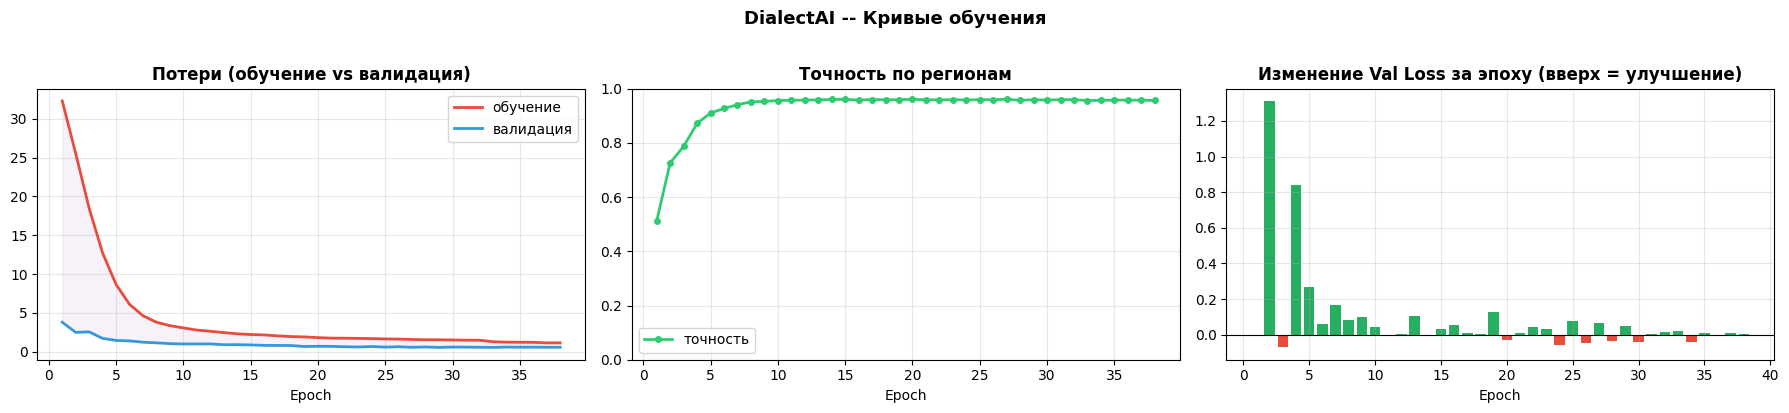

In [35]:
# 15c. MAIN -- Обучение модели

history = trainer.fit(epochs=EPOCHS)
save_artifacts(OUT_DIR, region_enc, n_regions, use_cache=USE_CACHE)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(history["epoch"], history["train_loss"], label="обучение", color="#e74c3c", linewidth=2)
axes[0].plot(history["epoch"], history["val_loss"],   label="валидация",   color="#3498db", linewidth=2)
axes[0].fill_between(history["epoch"], history["train_loss"], history["val_loss"], alpha=0.08, color="#9b59b6")
axes[0].set_title("Потери (обучение vs валидация)", fontweight="bold")
axes[0].legend(); axes[0].set_xlabel("Epoch"); axes[0].grid(alpha=0.3)

axes[1].plot(history["epoch"], history["region_acc"], label="точность",
             color="#2ecc71", linewidth=2, marker="o", markersize=4)
axes[1].set_ylim(0, 1); axes[1].set_title("Точность по регионам", fontweight="bold")
axes[1].legend(); axes[1].set_xlabel("Epoch"); axes[1].grid(alpha=0.3)

val_arr = np.array(history["val_loss"])
improvement = np.diff(val_arr, prepend=val_arr[0])
axes[2].bar(history["epoch"], -improvement,
            color=["#27ae60" if v < 0 else "#e74c3c" for v in improvement])
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_title("Изменение Val Loss за эпоху (вверх = улучшение)", fontweight="bold")
axes[2].set_xlabel("Epoch"); axes[2].grid(alpha=0.3)

plt.suptitle("DialectAI -- Кривые обучения", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "training_curves_extended.png", dpi=150, bbox_inches="tight")
plt.show()


Embeddings:   0%|          | 0/309 [00:00<?, ?it/s]

09:17:10  INFO  UMAP 20D for clustering...
C:\Users\podgo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
09:17:43  INFO  HDBSCAN on 20D embeddings...
09:17:43  INFO  Clusters: 13 | Noise: 8 (0.2%)
09:17:43  INFO  UMAP 2D for visualization...
C:\Users\podgo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
09:18:10  INFO  Plot -> runs\dialect_v5\dialect_map.png


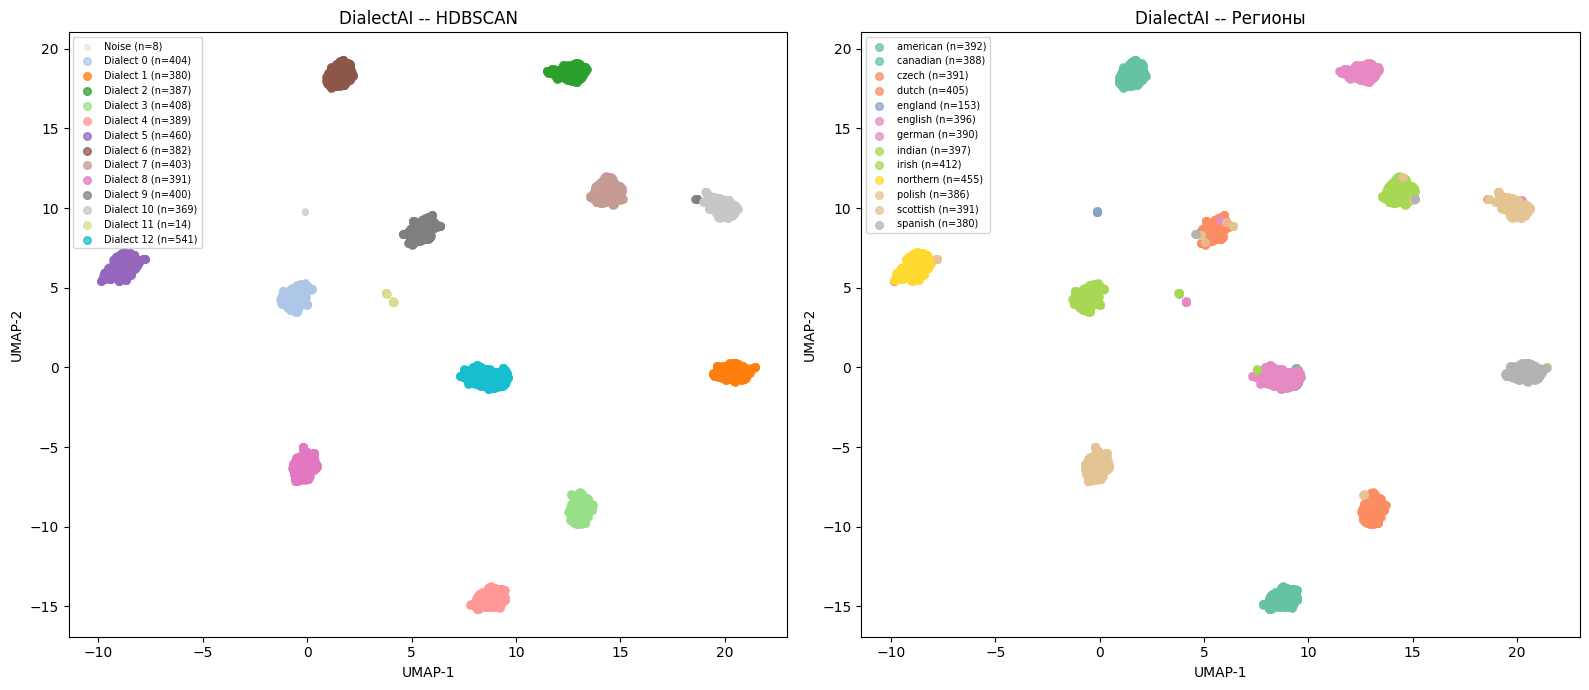

In [36]:
# 16. Clustering + visualization (after training)
model.load_state_dict(torch.load(OUT_DIR/"best_model.pt", map_location=device, weights_only=True))
embeddings, region_labels = extract_all_embeddings(model, val_loader)
cluster_labels, coords_2d = cluster_dialects(embeddings, OUT_DIR)
plot_dialect_map(coords_2d, cluster_labels, region_labels, region_enc,
                 title="DialectAI", save_path=OUT_DIR/"dialect_map.png")

In [37]:
# 17. Inference on new audio
predictor = Predictor(model, region_enc)

# Замените путь на реальный файл:
result = predictor.predict("AccentDataset/American_accent/american_accent_25.wav")
print("Region:", result["top_region"])

09:18:11  INFO  Predictor: LightDialectModel detected — loading HuBERT encoder for inference
C:\Users\podgo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of HubertModel were not initialized from the model checkpoint at facebook/hubert-large-ls960-ft and are newly initialized: ['hubert.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'hubert.encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
09:18:17  INFO  HuBERT: 3/24 trainable layers | params: 46,707,840/315,438,720 (14.8%)



  Region prediction:
   english                ###########################  1.000
   england                                             0.000
   american                                            0.000
   canadian                                            0.000
   czech                                               0.000
   dutch                                               0.000
   german                                              0.000
   indian                                              0.000
   irish                                               0.000
   northern                                            0.000
   polish                                              0.000
   scottish                                            0.000
   spanish                                             0.000
Region: english


In [38]:
# 17. Inference on new audio
predictor = Predictor(model, region_enc)

# Замените путь на реальный файл:
result = predictor.predict("AccentDataset/indian_accent/indian_accent_73.wav")
print("Region:", result["top_region"])

09:18:18  INFO  Predictor: LightDialectModel detected — loading HuBERT encoder for inference
Some weights of HubertModel were not initialized from the model checkpoint at facebook/hubert-large-ls960-ft and are newly initialized: ['hubert.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'hubert.encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
09:18:29  INFO  HuBERT: 3/24 trainable layers | params: 46,707,840/315,438,720 (14.8%)



  Region prediction:
   german                 ############################ 1.000
   american                                            0.000
   canadian                                            0.000
   czech                                               0.000
   dutch                                               0.000
   england                                             0.000
   english                                             0.000
   indian                                              0.000
   irish                                               0.000
   northern                                            0.000
   polish                                              0.000
   scottish                                            0.000
   spanish                                             0.000
Region: german


In [39]:
# 17. Inference on new audio
predictor = Predictor(model, region_enc)

# Замените путь на реальный файл:
result = predictor.predict("AccentDataset/British_accent/british_accent_15.wav")
print("Region:", result["top_region"])

09:18:30  INFO  Predictor: LightDialectModel detected — loading HuBERT encoder for inference
Some weights of HubertModel were not initialized from the model checkpoint at facebook/hubert-large-ls960-ft and are newly initialized: ['hubert.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'hubert.encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
09:18:32  INFO  HuBERT: 3/24 trainable layers | params: 46,707,840/315,438,720 (14.8%)



  Region prediction:
   english                ###################          0.712
   american               ######                       0.243
   england                                             0.026
   dutch                                               0.019
   canadian                                            0.000
   czech                                               0.000
   german                                              0.000
   indian                                              0.000
   irish                                               0.000
   northern                                            0.000
   polish                                              0.000
   scottish                                            0.000
   spanish                                             0.000
Region: english


Eval Val:   0%|          | 0/309 [00:00<?, ?it/s]

C:\Users\podgo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classification.py:2981: UserWarning: The y_pred values do not sum to one. Starting from 1.5 thiswill result in an error.
  warnings.warn(



══════════════════════════════════════════════════════════
  📊  Метрики качества — Val  (4936 образцов, 13 классов)
══════════════════════════════════════════════════════════
  Micro Accuracy                       0.9560   (4719/4936)
  UA  (Macro Recall) ★                 0.9105   ← главная при дисбалансе
  ──────────────────────────────────
  Macro F1                             0.8993
  Macro F0.5  (precision > recall)     0.8948
  Macro F2   (recall > precision)      0.9054
  ──────────────────────────────────
  ROC-AUC  (macro OvR)                 0.9920
  Cohen κ                              0.9522   (почти идеально)
  Log-loss                             0.5114
  Top-3 Accuracy                       0.9953
  Top-5 Accuracy                       0.9986
══════════════════════════════════════════════════════════

  TOP-10 классов по числу образцов:
          support  precision  recall  f1-score
northern      455      1.000   1.000     1.000
irish         412      0.998   0.978    

09:19:26  INFO  Confusion matrix -> runs\dialect_v5\confusion_val.png


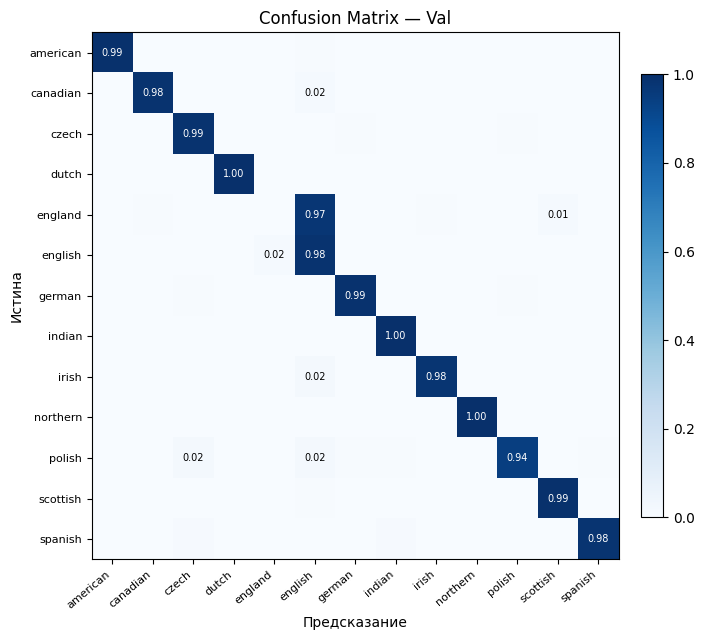

In [40]:
# 18. Полный набор метрик качества
#
# Реализует все метрики из документа «Приоритетные метрики»:
#   1. UA  — Unweighted Accuracy / Macro Recall     [ГЛАВНАЯ при дисбалансе]
#   2. F1, F0.5, F2                                 [основная метрика классификации]
#   3. ROC-AUC (macro OvR)                          [сравнение моделей]
#   4. Confusion Matrix (нормализованная, top-N)    [диагностика ошибок]
#   5. Cohen's κ                                    [поправка на случайность]
#   6. Log-loss                                     [калибровка уверенности]
#   7. Top-K Accuracy (K=3, K=5)                    [крупные таксономии]

def evaluate_model(model, loader, region_enc, out_dir=None, split_name="Val"):
    """
    Вычисляет все приоритетные метрики.

    Args:
        model:       обученная DialectModel или LightDialectModel
        loader:      DataLoader (val_loader / test_loader)
        region_enc:  LabelEncoder с именами регионов
        out_dir:     Path — куда сохранить confusion matrix (None = не сохранять)
        split_name:  подпись в заголовках ("Val", "Test", ...)

    Returns:
        dict с ключами: ua, accuracy, macro_f1, f05, f2,
                        auc, kappa, logloss, top3_acc, top5_acc, report_df
    """
    model.eval()
    r_true, r_pred_all, r_probs_all = [], [], []

    with torch.no_grad():
        for x, region in tqdm(loader, desc=f"Eval {split_name}", leave=False):
            x, region = x.to(device), region.to(device)
            with autocast(enabled=torch.cuda.is_available()):
                _, r_pred = model(x)
            probs = torch.softmax(r_pred, dim=1).cpu().float().numpy()
            r_true.extend(region.cpu().numpy())
            r_pred_all.extend(r_pred.argmax(1).cpu().numpy())
            r_probs_all.append(probs)

    r_true  = np.array(r_true)
    r_pred  = np.array(r_pred_all)
    r_probs = np.concatenate(r_probs_all, axis=0)
    n_cls   = len(region_enc.classes_)

    # ── 1. UA = Unweighted Accuracy = Macro Recall ───────────────
    # Единственная честная метрика при дисбалансе: равный вес каждому классу
    ua  = f1_score(r_true, r_pred, average="macro", zero_division=0)  # macro recall = macro F1 at beta→∞
    ua  = __import__("sklearn.metrics", fromlist=["recall_score"]).recall_score(
              r_true, r_pred, average="macro", zero_division=0)
    acc = accuracy_score(r_true, r_pred)

    # ── 2. Fβ-scores ─────────────────────────────────────────────
    # F1  : равный вес precision/recall
    # F0.5: precision вдвое важнее (идентификация акцентов)
    # F2  : recall важнее (детекция редких событий)
    f1  = f1_score(r_true, r_pred, average="macro", zero_division=0)
    f05 = fbeta_score(r_true, r_pred, beta=0.5, average="macro", zero_division=0)
    f2  = fbeta_score(r_true, r_pred, beta=2.0, average="macro", zero_division=0)

    # ── 3. ROC-AUC macro One-vs-Rest ─────────────────────────────
    # Порогонезависимая метрика разделимости классов
    try:
        present = np.unique(r_true)
        if len(present) == n_cls:
            auc = roc_auc_score(r_true, r_probs, multi_class="ovr",
                                average="macro", labels=np.arange(n_cls))
        else:
            auc = roc_auc_score(r_true, r_probs[:, present], multi_class="ovr",
                                average="macro", labels=present)
    except Exception as e:
        log.warning("ROC-AUC не вычислен: %s", e); auc = float("nan")

    # ── 4. Cohen's κ ─────────────────────────────────────────────
    # Поправка на случайное совпадение; важна при дисбалансе классов
    kappa = cohen_kappa_score(r_true, r_pred)

    # ── 5. Log-loss (Cross-Entropy) ───────────────────────────────
    # Штрафует за уверенные неправильные предсказания
    # Две модели с одинаковым F1 могут иметь разный logloss — лучше откалиброванная надёжнее
    try:
        ll = log_loss(r_true, r_probs, labels=np.arange(n_cls))
    except Exception as e:
        log.warning("Log-loss не вычислен: %s", e); ll = float("nan")

    # ── 6. Top-K Accuracy ─────────────────────────────────────────
    # При большом числе классов информативнее Top-1
    try:
        top3 = top_k_accuracy_score(r_true, r_probs, k=3, labels=np.arange(n_cls))
        top5 = top_k_accuracy_score(r_true, r_probs, k=5, labels=np.arange(n_cls))
    except Exception as e:
        log.warning("Top-K не вычислен: %s", e); top3 = top5 = float("nan")

    # ── Вывод ─────────────────────────────────────────────────────
    bar = "═" * 58
    kappa_word = ("почти идеально" if kappa > 0.8 else
                  "хорошо"         if kappa > 0.6 else
                  "умеренно"       if kappa > 0.4 else
                  "слабо"          if kappa > 0.2 else "плохо / случайно")
    print(f"\n{bar}")
    print(f"  📊  Метрики качества — {split_name}  ({len(r_true)} образцов, {n_cls} классов)")
    print(bar)
    print(f"  {'Micro Accuracy':<36} {acc:.4f}   ({int(acc*len(r_true))}/{len(r_true)})")
    print(f"  {'UA  (Macro Recall) ★':<36} {ua:.4f}   ← главная при дисбалансе")
    print(f"  {'──────────────────────────────────'}")
    print(f"  {'Macro F1':<36} {f1:.4f}")
    print(f"  {'Macro F0.5  (precision > recall)':<36} {f05:.4f}")
    print(f"  {'Macro F2   (recall > precision)':<36} {f2:.4f}")
    print(f"  {'──────────────────────────────────'}")
    print(f"  {'ROC-AUC  (macro OvR)':<36} {auc:.4f}")
    print(f"  {'Cohen κ':<36} {kappa:.4f}   ({kappa_word})")
    print(f"  {'Log-loss':<36} {ll:.4f}")
    print(f"  {'Top-3 Accuracy':<36} {top3:.4f}")
    print(f"  {'Top-5 Accuracy':<36} {top5:.4f}")
    print(bar)

    # ── Per-class breakdown ───────────────────────────────────────
    report = classification_report(
        r_true, r_pred,
        target_names=region_enc.classes_,
        output_dict=True, zero_division=0)
    df_rep = pd.DataFrame(report).T.iloc[:-3]
    df_rep["support"]  = df_rep["support"].astype(int)
    df_rep["f1-score"] = df_rep["f1-score"].round(3)
    df_rep["recall"]   = df_rep["recall"].round(3)
    df_rep["precision"]= df_rep["precision"].round(3)

    print("\n  TOP-10 классов по числу образцов:")
    top10 = df_rep.nlargest(10, "support")[["support","precision","recall","f1-score"]]
    print(top10.to_string())

    print("\n  ТОП-10 ХУДШИХ классов по F1 (минимум 3 образца):")
    worst = df_rep[df_rep["support"] >= 3].nsmallest(10, "f1-score")[["support","precision","recall","f1-score"]]
    print(worst.to_string())

    # ── Confusion Matrix ──────────────────────────────────────────
    save_cm = (out_dir / f"confusion_{split_name.lower()}.png") if out_dir else None
    plot_confusion_matrix_topn(r_true, r_pred, region_enc, top_n=20,
                               title=f"Confusion Matrix — {split_name}",
                               save_path=save_cm)

    return {"ua": ua, "accuracy": acc, "macro_f1": f1, "f05": f05, "f2": f2,
            "auc": auc, "kappa": kappa, "logloss": ll,
            "top3_acc": top3, "top5_acc": top5, "report_df": df_rep}


# ── Запуск на валидационной выборке ──────────────────────────────
model.load_state_dict(torch.load(OUT_DIR/"best_model.pt", map_location=device, weights_only=True))
val_metrics = evaluate_model(model, val_loader, region_enc, out_dir=OUT_DIR, split_name="Val")


## 19. Geo-linguistic map of accents

Visualises dialect probabilities on a world map. **English (RP)** is marked as the reference dialect (*).
Circle size = predicted probability; colour = dialect group.


In [41]:
# 19a. Географические координаты диалектов + упрощённая карта мира

DIALECT_GEO = {
    # ключ          : (lat,    lon,   описание,                    группа)
    "american"    : ( 39.5, -98.3, "Американский (General)",      "Америки"),
    "australian"  : (-25.3, 133.8, "Австралийский",               "Тихоокеанский"),
    "canadian"    : ( 56.1,-106.3, "Канадский",                   "Америки"),
    "czech"       : ( 49.8,  15.5, "Чешский (EFL)",               "Европа"),
    "dutch"       : ( 52.1,   5.3, "Нидерландский (EFL)",         "Европа"),
    "english"     : ( 52.4,  -1.5, "Британский RP [ЭТАЛОН]",      "Британские о-ва"),
    "german"      : ( 51.2,  10.5, "Немецкий (EFL)",              "Европа"),
    "indian"      : ( 20.6,  78.9, "Индийский",                   "Азия"),
    "irish"       : ( 53.4,  -8.2, "Ирландский",                  "Британские о-ва"),
    "northern"    : ( 54.9,  -3.2, "Северный английский",         "Британские о-ва"),
    "polish"      : ( 51.9,  19.1, "Польский (EFL)",              "Европа"),
    "scottish"    : ( 56.5,  -4.2, "Шотландский",                 "Британские о-ва"),
    "spanish"     : ( 40.4,  -3.7, "Испанский (EFL)",             "Европа"),
    "southafrican": (-30.6,  22.9, "Южноафриканский",             "Африка"),
    "newzealand"  : (-40.9, 174.9, "Новозеландский",              "Тихоокеанский"),
    "welsh"       : ( 52.1,  -3.8, "Уэльский",                  "Британские о-ва"),
}

GROUP_COLORS = {
    "Америка":         "#e74c3c",
    "Тихоокеанский":   "#8e44ad",
    "Европа":          "#3498db",
    "Британские о-ва": "#2ecc71",
    "Азия":            "#f39c12",
    "Африка":          "#1abc9c",
}

_CONTINENTS = {
    "Сев. Америка":  [(-168,72),(-60,72),(-52,47),(-57,45),(-68,44),(-82,42),
                      (-83,29),(-90,15),(-95,15),(-120,20),(-168,60),(-168,72)],
    "Юж. Америка":   [(-82,12),(-60,12),(-35,-5),(-32,-55),(-70,-55),(-82,12)],
    "Европа":        [(-12,36),(42,36),(42,47),(32,70),(5,71),(-18,65),(-12,36)],
    "Брит. о-ва":    [(-6,50),(2,51),(2,56),(-2,58),(-5,59),(-8,57),(-6,54),(-8,50),(-6,50)],
    "Африка":        [(-18,37),(52,37),(52,12),(44,-12),(35,-35),(-18,-35),(-18,37)],
    "Азия":          [(26,37),(145,37),(145,50),(135,73),(60,73),(32,70),(26,37)],
    "Индия":         [(68,37),(90,28),(80,8),(72,8),(62,23),(68,37)],
    "Австралия":     [(114,-22),(154,-22),(154,-39),(128,-39),(114,-30),(114,-22)],
}


def plot_geographic_prediction(region_probs, reference_dialect="english",
                                title="Геолингвистическая карта предсказания",
                                save_path=None):
    known = {k: v for k, v in region_probs.items() if k in DIALECT_GEO}
    if not known:
        print("Нет диалектов с известными координатами."); return

    top_dialect = max(known, key=known.get)
    fig = plt.figure(figsize=(18, 8), facecolor="#1a2035")
    ax_map = fig.add_axes([0.01, 0.05, 0.64, 0.88])
    ax_bar = fig.add_axes([0.69, 0.10, 0.28, 0.78])

    ax_map.set_facecolor("#1e3a5f")
    ax_map.set_xlim(-175, 185)
    ax_map.set_ylim(-55, 80)

    land_color = "#3d5a3e"
    for name, poly in _CONTINENTS.items():
        xs, ys = zip(*poly)
        ax_map.fill(xs, ys, color=land_color, alpha=0.85, linewidth=0)
        ax_map.plot(list(xs)+[xs[0]], list(ys)+[ys[0]],
                    color="#5a7a5c", linewidth=0.5, alpha=0.6)

    for lon in range(-180, 185, 30):
        ax_map.axvline(lon, color="white", alpha=0.07, linewidth=0.5)
    for lat in range(-50, 85, 20):
        ax_map.axhline(lat, color="white", alpha=0.07, linewidth=0.5)

    ax_map.set_xticks(range(-150, 180, 30))
    ax_map.set_yticks(range(-40, 80, 20))
    ax_map.set_xticklabels(
        [f"{abs(v)}Z{chr(176)}{'З' if v<0 else 'В'}" for v in range(-150,180,30)],
        fontsize=7, color="#aaa")
    ax_map.set_yticklabels(
        [f"{abs(v)}{chr(176)}{'Ю' if v<0 else 'С'}" for v in range(-40,80,20)],
        fontsize=7, color="#aaa")

    for dialect, prob in sorted(known.items(), key=lambda x: x[1]):
        lat, lon, label, group = DIALECT_GEO[dialect]
        color  = GROUP_COLORS.get(group, "white")
        is_ref = (dialect == reference_dialect)
        is_top = (dialect == top_dialect)

        if is_top:
            ax_map.scatter(lon, lat, s=prob*1600+80, color=color, alpha=0.15,
                           edgecolors="none", zorder=3)
        marker = "*" if is_ref else ("D" if is_top else "o")
        size   = max(prob * 900 + (60 if is_ref else 10), 20)
        ax_map.scatter(lon, lat, s=size, c=color, marker=marker,
                       edgecolors="white" if (is_ref or is_top) else color,
                       linewidths=1.5 if is_ref else 0.8,
                       alpha=0.95 if prob > 0.01 else 0.3, zorder=5)

        if prob > 0.03 or is_ref:
            suf = " (*)" if is_ref else ""
            ax_map.annotate(f"{label.split()[0]} {prob:.1%}{suf}",
                            (lon, lat), xytext=(lon+3, lat+2.5), fontsize=8,
                            color="white", fontweight="bold" if is_top else "normal",
                            bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.5, ec="none"),
                            zorder=6)

    for grp, col in GROUP_COLORS.items():
        ax_map.scatter([], [], c=col, s=60, label=grp, alpha=0.9)
    ax_map.scatter([], [], marker="*", c="white", s=120, label="Эталон (RP)")
    ax_map.scatter([], [], marker="D", c="white", s=80,  label="Топ-предсказание")
    ax_map.legend(loc="lower left", fontsize=7, framealpha=0.7,
                  facecolor="#1a2035", labelcolor="white", ncol=2,
                  title="Группы диалектов", title_fontsize=7)
    ax_map.set_title(title, color="white", fontsize=12, fontweight="bold", pad=10)
    ax_map.set_xlabel("Долгота", color="#aaa", fontsize=8)
    ax_map.set_ylabel("Широта",  color="#aaa", fontsize=8)
    for sp in ax_map.spines.values(): sp.set_edgecolor("#444")

    ax_bar.set_facecolor("#12192a")
    sorted_items = sorted(known.items(), key=lambda x: -x[1])
    dials = [d for d,_ in sorted_items]
    probs = [p for _,p in sorted_items]
    cols  = [GROUP_COLORS.get(DIALECT_GEO[d][3], "gray") for d in dials]
    bars  = ax_bar.barh(range(len(dials)), probs, color=cols, height=0.7, edgecolor="none")
    for i, d in enumerate(dials):
        if d == reference_dialect:
            bars[i].set_edgecolor("gold"); bars[i].set_linewidth(2)
        if d == top_dialect:
            bars[i].set_alpha(1.0)
    ax_bar.set_yticks(range(len(dials)))
    ax_bar.set_yticklabels(
        [f"{d}{'  (*)'if d==reference_dialect else('  [топ]'if d==top_dialect else '')}"
         for d in dials], fontsize=8, color="white")
    for i, (p, bar) in enumerate(zip(probs, bars)):
        ax_bar.text(p+0.004, i, f"{p:.1%}", va="center", fontsize=8, color="white")
    ax_bar.set_xlim(0, max(probs)*1.28)
    ax_bar.set_xlabel("Вероятность", color="white", fontsize=9)
    ax_bar.set_title("Распределение вероятностей", color="white", fontsize=9, pad=8)
    ax_bar.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    for sp in ax_bar.spines.values(): sp.set_edgecolor("#333")
    ax_bar.tick_params(colors="#aaa")

    fig.patch.set_facecolor("#1a2035")
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
        log.info("Геокарта сохранена -> %s", save_path)
    plt.show()
    return fig

print("DIALECT_GEO и plot_geographic_prediction() определены")
print(f"  Диалектов с координатами: {len(DIALECT_GEO)}")


DIALECT_GEO и plot_geographic_prediction() определены
  Диалектов с координатами: 16


## 20. Standard English Conformity Analysis

**English (Received Pronunciation)** = reference dialect.

Analysis includes:
1. **Centroid distance** -- cosine distance in HuBERT embedding space from each dialect centroid to the 'english' centroid
2. **Conformity score** = 1 - distance (0..1, higher = closer to standard)
3. **Dendrogram** -- hierarchical clustering of dialect centroids
4. **Pairwise heatmap** -- cosine distance matrix between all dialect pairs


C:\Users\podgo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of HubertModel were not initialized from the model checkpoint at facebook/hubert-large-ls960-ft and are newly initialized: ['hubert.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'hubert.encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
09:19:35  INFO  HuBERT: 3/24 trainable layers | params: 46,707,840/315,438,720 (14.8%)
09:19:44  INFO  Вычисление центроидов из 32907 файлов ...


Центроиды:   0%|          | 0/32907 [00:00<?, ?it/s]

09:29:14  INFO  Центроиды вычислены для 13 диалектов



  Анализ соответствия (эталон: 'english')
    #  Диалект             Conformity   Расстояние
  -------------------------------------------------------
    1  english                 1.0000       0.0000  ##############################  [ЭТАЛОН]
    2  england                 0.9997       0.0003  #############################
    3  american                0.0000       1.1971  
    4  canadian                0.0000       1.2672  
    5  czech                   0.0000       1.2542  
    6  dutch                   0.0000       1.3120  
    7  german                  0.0000       1.2563  
    8  indian                  0.0000       1.2089  
    9  irish                   0.0000       1.1160  
   10  northern                0.0000       1.2408  
   11  polish                  0.0000       1.3416  
   12  scottish                0.0000       1.1637  
   13  spanish                 0.0000       1.1437  


09:29:14  INFO  Conformity plot сохранён.


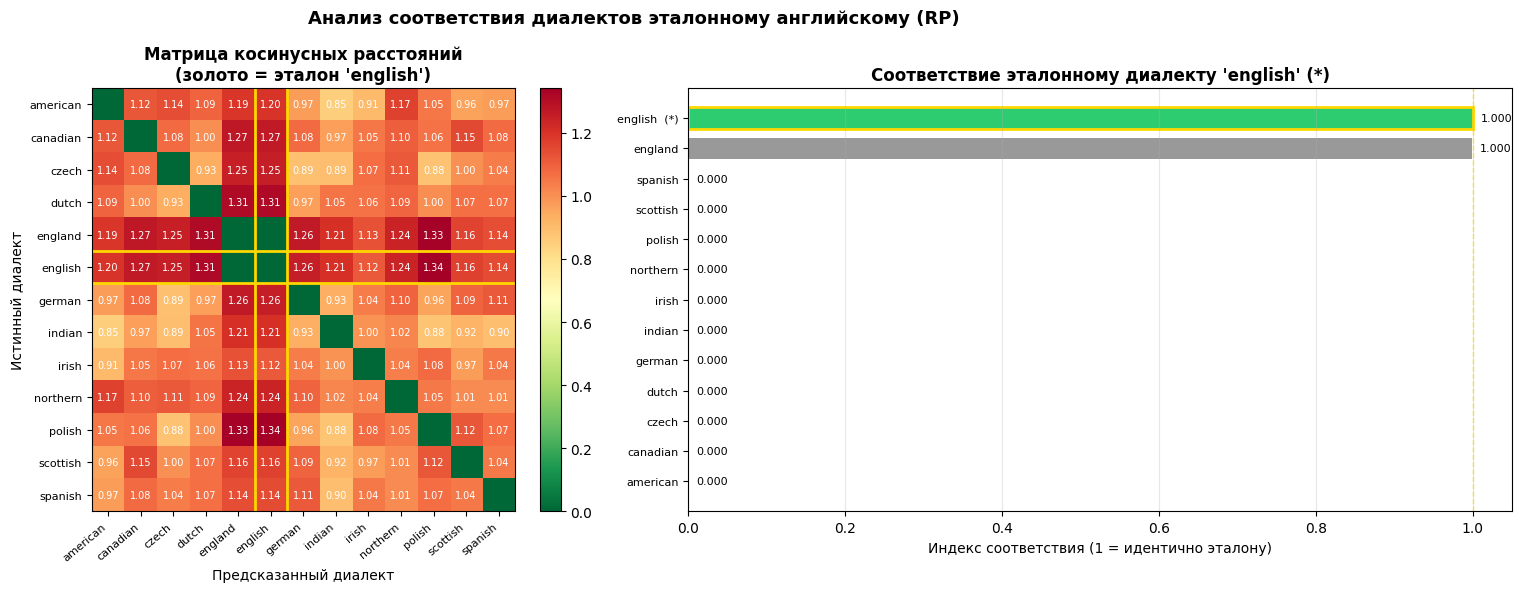

09:29:15  INFO  Дендрограмма сохранена.


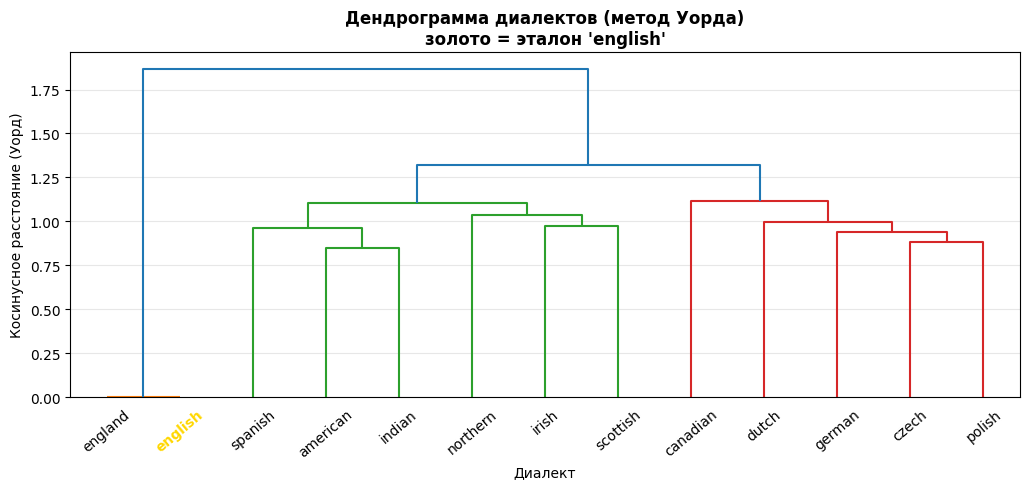

In [42]:
# 20a. Вычисление центроидов диалектов + Conformity Score

from scipy.spatial.distance import cosine as cosine_dist
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

REFERENCE_DIALECT = "english"   # Эталонный диалект (RP)

@torch.no_grad()
def compute_dialect_centroids(model, dataset_root, region_enc, max_per_class=50):
    model.eval()
    classes  = list(region_enc.classes_)
    buffers  = {c: [] for c in classes}
    is_light = isinstance(model, LightDialectModel)
    hubert_enc = None
    if is_light:
        hubert_enc = HubertEncoder(freeze_feature_extractor=True).to(device).eval()

    wav_files = list(Path(dataset_root).glob("*.wav"))
    log.info("Вычисление центроидов из %d файлов ...", len(wav_files))
    for wav_path in tqdm(wav_files, desc="Центроиды"):
        region = region_from_stem(wav_path.stem)
        if region is None or region not in buffers: continue
        if len(buffers[region]) >= max_per_class: continue
        try:
            audio = load_audio(str(wav_path), random_crop=False)
            x = torch.tensor(audio).unsqueeze(0).to(device)
            with autocast(enabled=torch.cuda.is_available()):
                if is_light:
                    he = hubert_enc(x)
                    mf = int(MAX_SEC * 50)
                    if he.size(1) > mf: he = he[:, :mf, :]
                    emb, _ = model(he)
                else:
                    emb, _ = model(x)
            buffers[region].append(emb.cpu().float().numpy().squeeze())
        except Exception as e:
            log.warning("Пропуск %s: %s", wav_path.name, e)

    if is_light and hubert_enc is not None:
        del hubert_enc; torch.cuda.empty_cache()

    centroids = {}
    for region, vecs in buffers.items():
        if vecs:
            centroids[region] = np.mean(vecs, axis=0)
    log.info("Центроиды вычислены для %d диалектов", len(centroids))
    return centroids


def analyze_conformity(centroids, reference=REFERENCE_DIALECT, save_dir=None):
    if reference not in centroids:
        print(f"Эталон '{reference}' не найден. Доступные: {sorted(centroids.keys())}")
        return pd.DataFrame()

    dialects = sorted(centroids.keys())
    ref_vec  = centroids[reference]

    # Conformity Score
    rows = []
    for d in dialects:
        dist  = float(cosine_dist(centroids[d], ref_vec))
        score = max(0.0, 1.0 - dist)
        geo   = DIALECT_GEO.get(d, (None, None, d, "Неизвестно"))
        rows.append({"dialect": d, "cosine_distance": round(dist, 4),
                     "conformity_score": round(score, 4), "group": geo[3]})

    df = pd.DataFrame(rows).sort_values("conformity_score", ascending=False).reset_index(drop=True)

    print("\n" + "="*65)
    print(f"  Анализ соответствия (эталон: '{reference}')")
    print("="*65)
    print(f"  {'#':>3}  {'Диалект':<18}  {'Conformity':>10}  {'Расстояние':>11}")
    print("  " + "-"*55)
    for i, row in df.iterrows():
        star = "  [ЭТАЛОН]" if row["dialect"] == reference else ""
        bar  = "#" * int(row["conformity_score"] * 30)
        print(f"  {i+1:>3}  {row['dialect']:<18}  {row['conformity_score']:>10.4f}"
              f"  {row['cosine_distance']:>11.4f}  {bar}{star}")
    print("="*65)

    # ── Матрица попарных расстояний ───────────────────────────────
    n = len(dialects)
    dist_matrix = np.zeros((n, n))
    for i, d1 in enumerate(dialects):
        for j, d2 in enumerate(dialects):
            if i == j:
                dist_matrix[i, j] = 0.0  # диагональ строго 0 — исправление ValueError
            else:
                v = float(cosine_dist(centroids[d1], centroids[d2]))
                dist_matrix[i, j] = max(0.0, v)  # clip floating-point noise

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Тепловая карта
    im = axes[0].imshow(dist_matrix, cmap="RdYlGn_r", vmin=0, vmax=dist_matrix.max())
    axes[0].set_xticks(range(n))
    axes[0].set_xticklabels(dialects, rotation=40, ha="right", fontsize=8)
    axes[0].set_yticks(range(n))
    axes[0].set_yticklabels(dialects, fontsize=8)
    for i in range(n):
        for j in range(n):
            v = dist_matrix[i, j]
            if v > 0.005:
                axes[0].text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                             color="white" if v > dist_matrix.max()*0.6 else "black")
    if reference in dialects:
        ri = dialects.index(reference)
        for dlt in [-0.5, 0.5]:
            axes[0].axhline(ri+dlt, color="gold", linewidth=2)
            axes[0].axvline(ri+dlt, color="gold", linewidth=2)
    plt.colorbar(im, ax=axes[0], fraction=0.04, pad=0.03)
    axes[0].set_title(f"Матрица косинусных расстояний\n(золото = эталон '{reference}')",
                      fontweight="bold")
    axes[0].set_xlabel("Предсказанный диалект")
    axes[0].set_ylabel("Истинный диалект")

    # Bar chart
    df_s = df.sort_values("conformity_score")
    cols = [GROUP_COLORS.get(r["group"], "#999") for _, r in df_s.iterrows()]
    bars = axes[1].barh(range(len(df_s)), df_s["conformity_score"],
                        color=cols, height=0.7, edgecolor="none")
    for i, (_, row) in enumerate(df_s.iterrows()):
        if row["dialect"] == reference:
            bars[i].set_edgecolor("gold"); bars[i].set_linewidth(2)
    axes[1].set_yticks(range(len(df_s)))
    axes[1].set_yticklabels(
        [f"{r['dialect']}{'  (*)' if r['dialect']==reference else ''}"
         for _, r in df_s.iterrows()], fontsize=8)
    axes[1].set_xlim(0, 1.05)
    axes[1].axvline(1.0, color="gold", linewidth=1, linestyle="--", alpha=0.7)
    for i, (_, row) in enumerate(df_s.iterrows()):
        axes[1].text(row["conformity_score"]+0.01, i,
                     f"{row['conformity_score']:.3f}", va="center", fontsize=8)
    axes[1].set_xlabel("Индекс соответствия (1 = идентично эталону)")
    axes[1].set_title(f"Соответствие эталонному диалекту '{reference}' (*)",
                      fontweight="bold")
    axes[1].grid(axis="x", alpha=0.3)

    plt.suptitle("Анализ соответствия диалектов эталонному английскому (RP)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    if save_dir:
        plt.savefig(Path(save_dir) / "conformity_analysis.png", dpi=150, bbox_inches="tight")
        log.info("Conformity plot сохранён.")
    plt.show()

    # ── Дендрограмма ─────────────────────────────────────────────
    # Симметризуем и жёстко зануляем диагональ перед squareform
    dist_sym = (dist_matrix + dist_matrix.T) / 2.0
    np.fill_diagonal(dist_sym, 0.0)          # гарантируем точный 0
    condensed = squareform(dist_sym, checks=False)  # checks=False — доверяем матрице

    Z = linkage(condensed, method="ward")

    fig2, ax_d = plt.subplots(figsize=(max(10, n*0.8), 5))
    dn = dendrogram(Z, labels=dialects, ax=ax_d, leaf_rotation=40, leaf_font_size=10,
                    color_threshold=0.7*max(Z[:, 2]))
    for lbl in ax_d.get_xticklabels():
        if lbl.get_text() == reference:
            lbl.set_color("gold"); lbl.set_fontweight("bold")
    ax_d.set_title(
        f"Дендрограмма диалектов (метод Уорда)\n"
        f"золото = эталон '{reference}'",
        fontweight="bold")
    ax_d.set_ylabel("Косинусное расстояние (Уорд)")
    ax_d.set_xlabel("Диалект")
    ax_d.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    if save_dir:
        plt.savefig(Path(save_dir) / "dendrogram.png", dpi=150, bbox_inches="tight")
        log.info("Дендрограмма сохранена.")
    plt.show()

    return df


# ── Запуск ────────────────────────────────────────────────────────
centroids = compute_dialect_centroids(model, DATASET_ROOT, region_enc)
conformity_df = analyze_conformity(centroids, reference=REFERENCE_DIALECT, save_dir=OUT_DIR)


## 21. Enhanced PredictorV2 -- geo map + Conformity Score

Single call: audio -> dialect + conformity score + geo-linguistic world map.


In [43]:
# 21. PredictorV2 -- with geographic map and conformity score

class PredictorV2(Predictor):
    def __init__(self, model, region_enc, centroids=None, reference=REFERENCE_DIALECT):
        super().__init__(model, region_enc)
        self.centroids = centroids
        self.reference = reference

    def _conformity(self, emb_np):
        if self.centroids is None or self.reference not in self.centroids:
            return None, None
        ref_vec = self.centroids[self.reference]
        dist = float(cosine_dist(emb_np.flatten(), ref_vec))
        return max(0.0, 1.0 - dist), dist

    @staticmethod
    def _conformity_label(score):
        if score is None: return "--"
        if score >= 0.90: return "Очень близко к эталону (RP)"
        if score >= 0.75: return "Близко к эталону"
        if score >= 0.55: return "Умеренное отклонение"
        return "Значительное отклонение от RP"

    @torch.no_grad()
    def predict_v2(self, audio_path, show_map=True):
        audio = load_audio(audio_path, random_crop=False)
        x = torch.tensor(audio).unsqueeze(0).to(device)

        with autocast(enabled=torch.cuda.is_available()):
            if self._is_light:
                he = self._hubert(x)
                mf = int(MAX_SEC * 50)
                if he.size(1) > mf: he = he[:, :mf, :]
                emb, r_logits = self.model(he)
            else:
                emb, r_logits = self.model(x)

        r_probs    = torch.softmax(r_logits, dim=1).squeeze().cpu().float().numpy()
        region_res = {n: round(float(p), 4) for n, p in zip(self.region_enc.classes_, r_probs)}
        top_r      = max(region_res, key=region_res.get)
        emb_np     = emb.cpu().float().numpy()
        conf_score, conf_dist = self._conformity(emb_np)

        print("\n" + "="*55)
        print("  Прогноз региона:")
        for n, p in sorted(region_res.items(), key=lambda kv: -kv[1]):
            ref_mark = "  [ЭТАЛОН]" if n == self.reference else ""
            print(f"   {n:<20} {'#'*int(float(p)*28):<28} {float(p):.3f}{ref_mark}")
        print("="*55)
        print(f"  Top dialect  : {top_r}")
        geo = DIALECT_GEO.get(top_r)
        if geo:
            print(f"  Region       : {geo[2]}  (lat={geo[0]:.1f}, lon={geo[1]:.1f})")
        if conf_score is not None:
            print(f"  Conformity   : {conf_score:.4f}  -- {self._conformity_label(conf_score)}")
            print(f"  Dist/ref     : {conf_dist:.4f}  (reference = '{self.reference}')")
        print("="*55)

        if show_map:
            fname = Path(audio_path).stem
            plot_geographic_prediction(
                region_res, reference_dialect=self.reference,
                title=f"Geo map: {fname}",
                save_path=OUT_DIR / f"geomap_{fname}.png"
            )

        return {"top_region": top_r, "region_probs": region_res, "embedding": emb_np,
                "conformity": conf_score, "cosine_dist": conf_dist,
                "conformity_tag": self._conformity_label(conf_score)}


predictor_v2 = PredictorV2(model, region_enc, centroids=centroids, reference=REFERENCE_DIALECT)
print("PredictorV2 ready. Usage:  result = predictor_v2.predict_v2('path/to/audio.wav')")


09:29:15  INFO  Predictor: LightDialectModel detected — loading HuBERT encoder for inference
C:\Users\podgo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of HubertModel were not initialized from the model checkpoint at facebook/hubert-large-ls960-ft and are newly initialized: ['hubert.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'hubert.encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
09:29:18  INFO  HuBERT: 3/24 trainable layers | params: 46,707,840/315,438,720 (14.8%)


PredictorV2 ready. Usage:  result = predictor_v2.predict_v2('path/to/audio.wav')


## 22. Extended Quality Metrics

### 22a. Per-class ROC curves (One-vs-Rest)
### 22b. Calibration diagram (reliability curve)
### 22c. Radar chart + Precision vs Recall scatter


ROC eval:   0%|          | 0/309 [00:00<?, ?it/s]

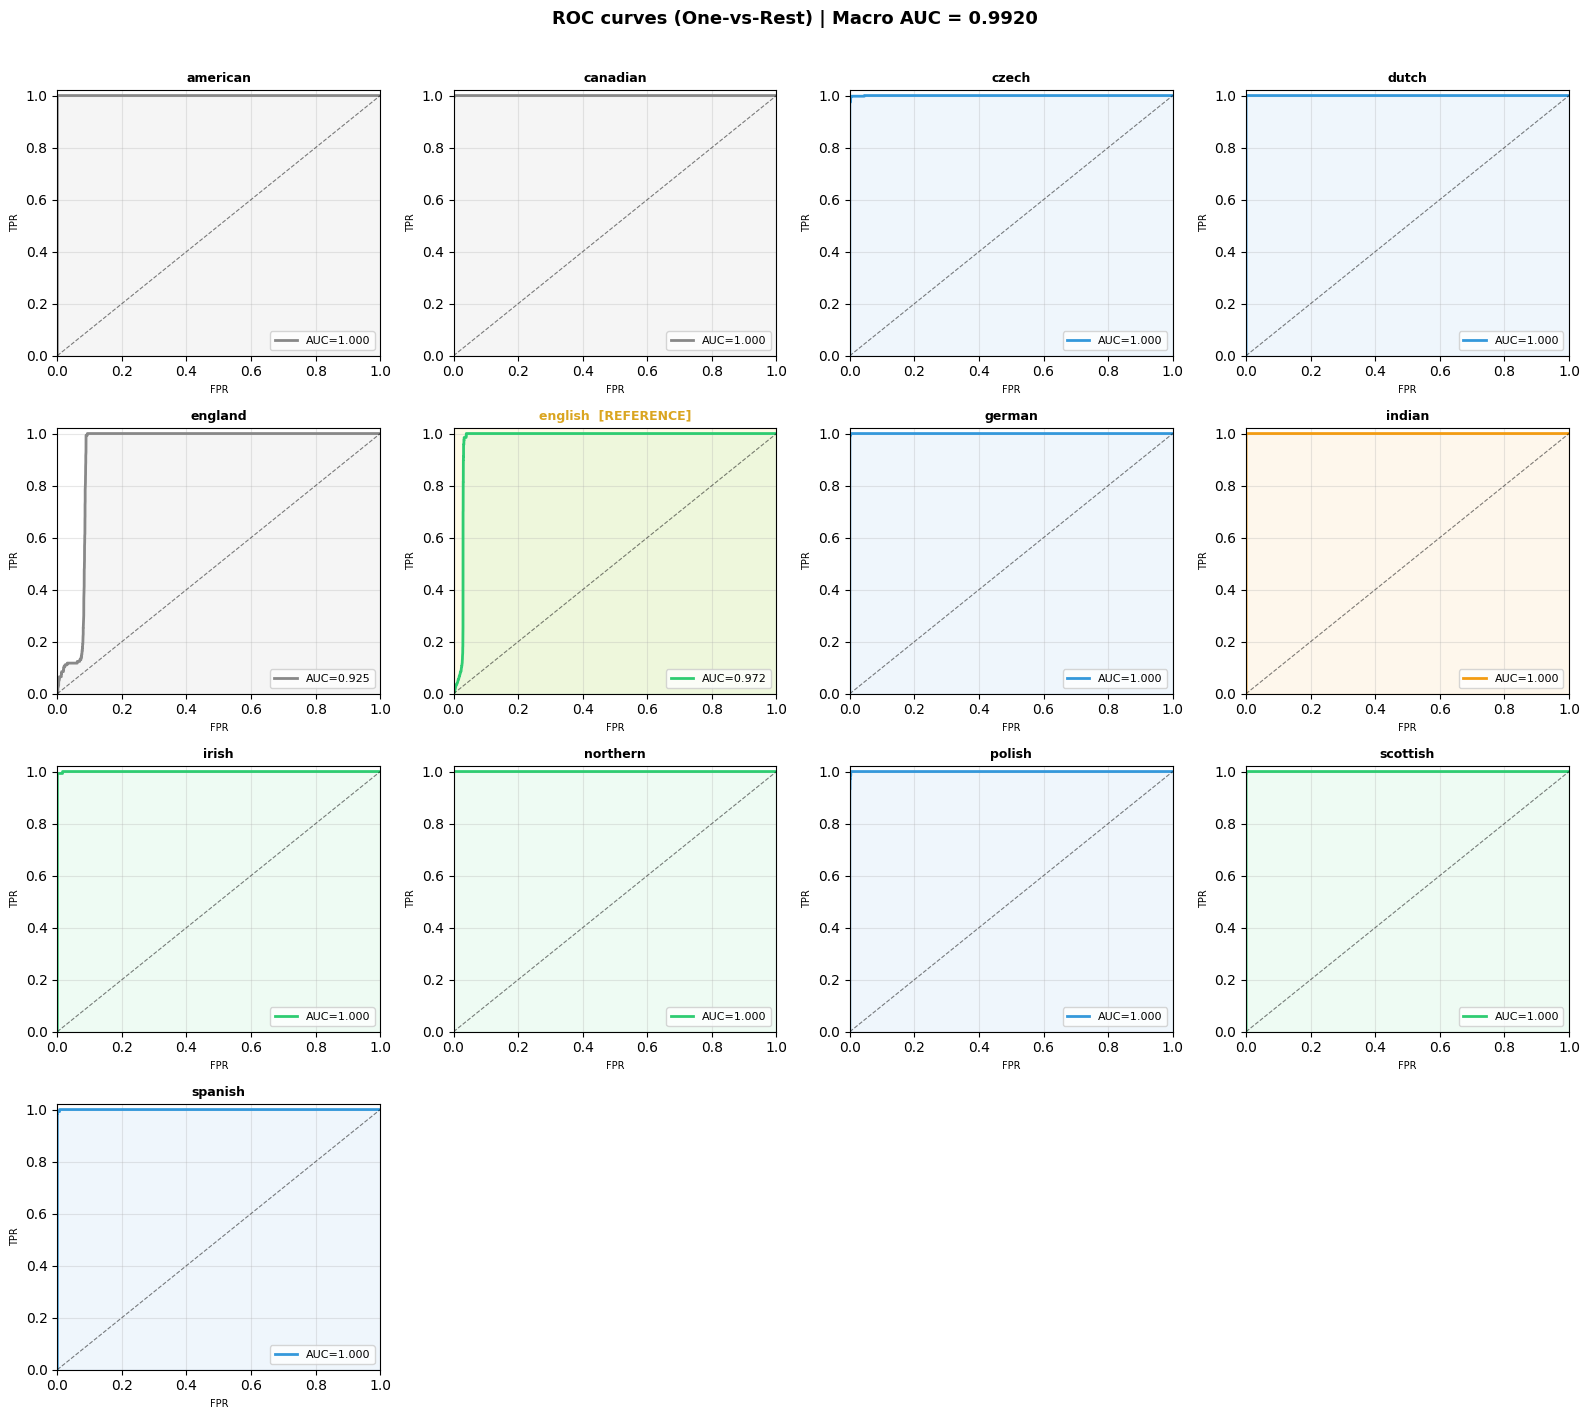

In [44]:
# 22a. Per-class ROC curves (One-vs-Rest)

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

def plot_per_class_roc(model, loader, region_enc, save_path=None):
    model.eval()
    r_true, r_probs_all = [], []
    classes = region_enc.classes_
    n_cls   = len(classes)

    with torch.no_grad():
        for x, region in tqdm(loader, desc="ROC eval", leave=False):
            x, region = x.to(device), region.to(device)
            with autocast(enabled=torch.cuda.is_available()):
                _, r_pred = model(x)
            probs = torch.softmax(r_pred, dim=1).cpu().float().numpy()
            r_true.extend(region.cpu().numpy())
            r_probs_all.append(probs)

    r_true  = np.array(r_true)
    r_probs = np.concatenate(r_probs_all, axis=0)
    y_bin   = label_binarize(r_true, classes=np.arange(n_cls))
    present = set(np.unique(r_true))

    ncols = min(n_cls, 4)
    nrows = math.ceil(n_cls / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3.5))
    axes = np.array(axes).flatten()

    aucs = []
    for i, cls_name in enumerate(classes):
        ax = axes[i]
        if i not in present:
            ax.set_visible(False); continue
        fpr, tpr, _ = roc_curve(y_bin[:, i], r_probs[:, i])
        roc_val = auc(fpr, tpr)
        aucs.append(roc_val)
        color = GROUP_COLORS.get(DIALECT_GEO.get(cls_name, (0,0,cls_name,"Unknown"))[3], "#888")
        ax.plot(fpr, tpr, color=color, linewidth=2, label=f"AUC={roc_val:.3f}")
        ax.plot([0,1],[0,1],"k--", linewidth=0.8, alpha=0.5)
        ax.fill_between(fpr, tpr, alpha=0.08, color=color)
        ax.set_xlim(0,1); ax.set_ylim(0,1.02)
        ax.set_title(cls_name, fontsize=9, fontweight="bold")
        ax.set_xlabel("FPR", fontsize=7); ax.set_ylabel("TPR", fontsize=7)
        ax.legend(fontsize=8, loc="lower right")
        ax.grid(alpha=0.3)
        # Mark reference dialect
        if cls_name == REFERENCE_DIALECT:
            ax.set_facecolor("#fffbe6")
            ax.set_title(cls_name + "  [REFERENCE]", fontsize=9, fontweight="bold", color="goldenrod")

    for j in range(n_cls, len(axes)):
        axes[j].set_visible(False)

    macro_auc = float(np.mean(aucs)) if aucs else float("nan")
    plt.suptitle(f"ROC curves (One-vs-Rest) | Macro AUC = {macro_auc:.4f}",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

plot_per_class_roc(model, val_loader, region_enc, save_path=OUT_DIR/"roc_per_class.png")


Калибровка:   0%|          | 0/309 [00:00<?, ?it/s]

09:30:03  INFO  Калибровочный график сохранён -> runs\dialect_v5\calibration.png


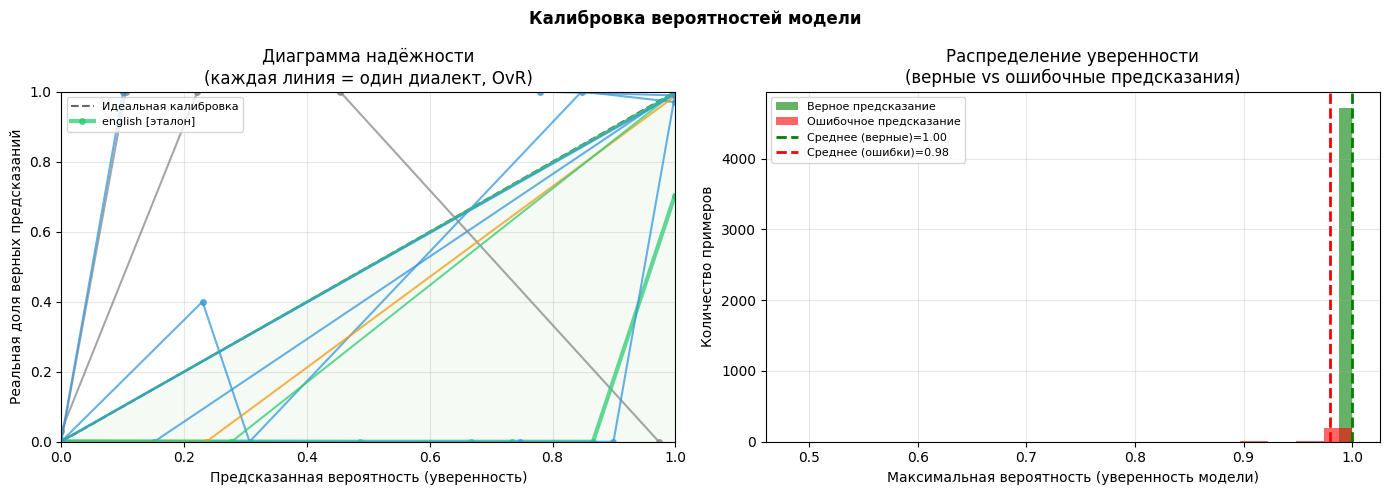

In [45]:
# 22б. Калибровочная диаграмма (надёжность вероятностей)

from sklearn.calibration import calibration_curve

def plot_calibration(model, loader, region_enc, n_bins=10, save_path=None):
    model.eval()
    r_true_all, r_probs_all = [], []
    n_cls = len(region_enc.classes_)

    with torch.no_grad():
        for x, region in tqdm(loader, desc="Калибровка", leave=False):
            x, region = x.to(device), region.to(device)
            with autocast(enabled=torch.cuda.is_available()):
                _, r_pred = model(x)
            probs = torch.softmax(r_pred, dim=1).cpu().float().numpy()
            r_true_all.extend(region.cpu().numpy())
            r_probs_all.append(probs)

    r_true  = np.array(r_true_all)
    r_probs = np.concatenate(r_probs_all, axis=0)
    y_bin   = label_binarize(r_true, classes=np.arange(n_cls))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.plot([0,1],[0,1], "k--", linewidth=1.5,
            label="Идеальная калибровка", alpha=0.6)
    for i, cls_name in enumerate(region_enc.classes_):
        if i not in np.unique(r_true): continue
        prob_true, prob_pred = calibration_curve(
            y_bin[:, i], r_probs[:, i], n_bins=n_bins, strategy="uniform")
        color = GROUP_COLORS.get(
            DIALECT_GEO.get(cls_name, (0,0,cls_name,"Неизвестно"))[3], "#888")
        lw = 3 if cls_name == REFERENCE_DIALECT else 1.5
        ax.plot(prob_pred, prob_true, color=color, linewidth=lw, alpha=0.75,
                marker="o", markersize=4,
                label=f"{cls_name} [эталон]" if cls_name == REFERENCE_DIALECT else None)

    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel("Предсказанная вероятность (уверенность)")
    ax.set_ylabel("Реальная доля верных предсказаний")
    ax.set_title("Диаграмма надёжности\n(каждая линия = один диалект, OvR)")
    ax.fill_between([0,1],[0,1], alpha=0.04, color="green")
    ax.legend(loc="upper left", fontsize=8); ax.grid(alpha=0.3)

    ax2 = axes[1]
    max_probs = r_probs.max(axis=1)
    correct   = (r_probs.argmax(axis=1) == r_true)
    ax2.hist(max_probs[correct],  bins=20, alpha=0.6,
             color="green", label="Верное предсказание")
    ax2.hist(max_probs[~correct], bins=20, alpha=0.6,
             color="red",   label="Ошибочное предсказание")
    mc = max_probs[correct].mean()  if correct.sum() > 0 else 0
    mw = max_probs[~correct].mean() if (~correct).sum() > 0 else 0
    ax2.axvline(mc, color="green", linestyle="--", linewidth=2,
                label=f"Среднее (верные)={mc:.2f}")
    ax2.axvline(mw, color="red",   linestyle="--", linewidth=2,
                label=f"Среднее (ошибки)={mw:.2f}")
    ax2.set_xlabel("Максимальная вероятность (уверенность модели)")
    ax2.set_ylabel("Количество примеров")
    ax2.set_title("Распределение уверенности\n(верные vs ошибочные предсказания)")
    ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

    plt.suptitle("Калибровка вероятностей модели",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        log.info("Калибровочный график сохранён -> %s", save_path)
    plt.show()

plot_calibration(model, val_loader, region_enc,
                 save_path=OUT_DIR/"calibration.png")


09:30:04  INFO  Радарная диаграмма сохранена -> runs\dialect_v5\radar_chart.png


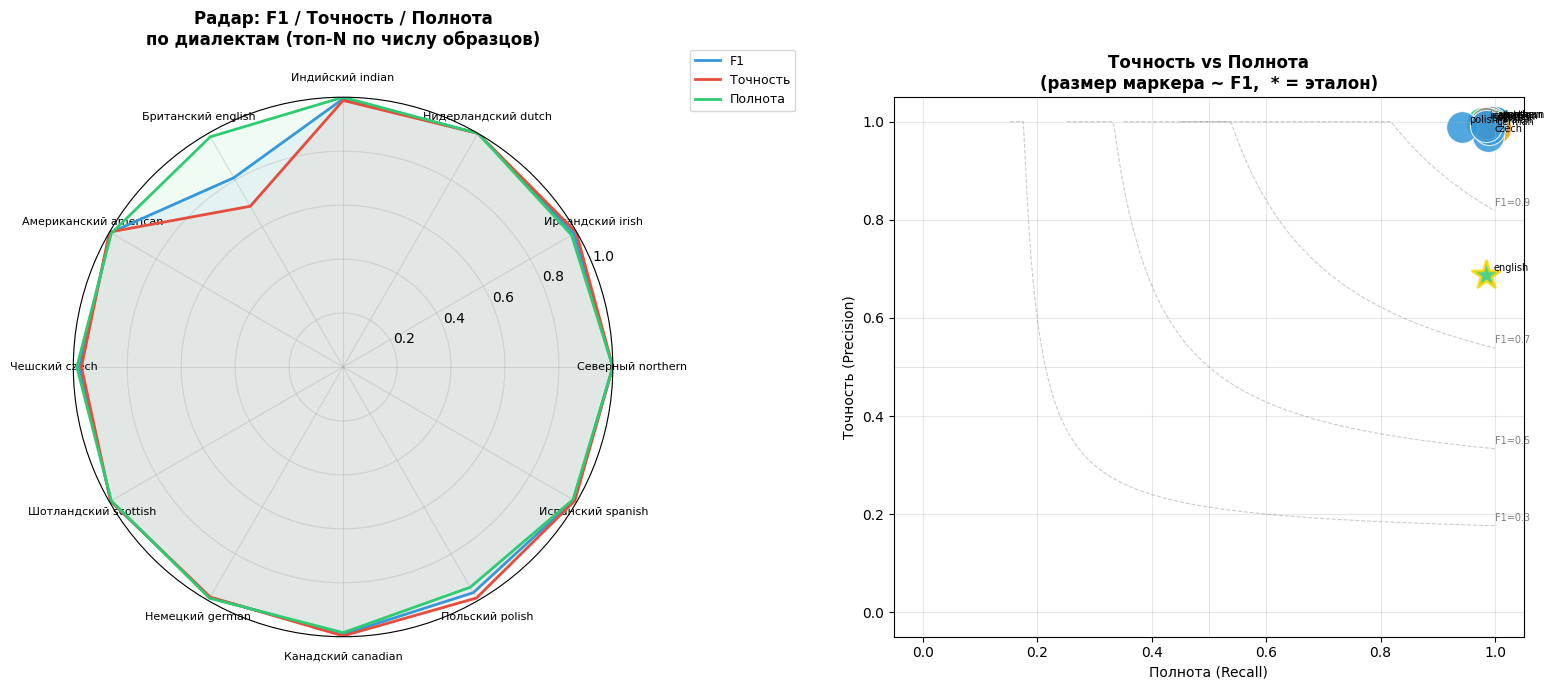

In [46]:
# 22в. Радарная диаграмма + Точность vs Полнота

def plot_radar_chart(report_df, save_path=None, top_n=12):
    df = report_df.nlargest(top_n, "support")
    labels = list(df.index)
    N = len(labels)
    if N < 3:
        print("Слишком мало классов для радарной диаграммы."); return

    fig = plt.figure(figsize=(16, 7))

    ax_r = fig.add_subplot(121, polar=True)
    angles = [n / N * 2 * math.pi for n in range(N)]
    angles += angles[:1]

    metrics_radar = {
        "F1":       [float(df.loc[l, "f1-score"]) for l in labels],
        "Точность": [float(df.loc[l, "precision"]) for l in labels],
        "Полнота":  [float(df.loc[l, "recall"])    for l in labels],
    }
    palette = ["#3498db", "#e74c3c", "#2ecc71"]
    for (mname, vals), color in zip(metrics_radar.items(), palette):
        vp = vals + vals[:1]
        ax_r.plot(angles, vp, color=color, linewidth=2, label=mname)
        ax_r.fill(angles, vp, color=color, alpha=0.07)

    tick_labels = []
    for l in labels:
        geo = DIALECT_GEO.get(l)
        if geo:
            short = geo[2].split()[0]
            tick_labels.append(f"{short} {l}")
        else:
            tick_labels.append(l)
    ax_r.set_xticks(angles[:-1])
    ax_r.set_xticklabels(tick_labels, fontsize=8)
    ax_r.set_ylim(0, 1)
    ax_r.set_title("Радар: F1 / Точность / Полнота\nпо диалектам (топ-N по числу образцов)",
                   fontweight="bold", pad=20)
    ax_r.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=9)
    ax_r.grid(alpha=0.4)

    ax_s = fig.add_subplot(122)
    for label in labels:
        p  = float(df.loc[label, "precision"])
        r  = float(df.loc[label, "recall"])
        f1 = float(df.loc[label, "f1-score"])
        grp = DIALECT_GEO.get(label, (0,0,label,"Неизвестно"))[3]
        c = GROUP_COLORS.get(grp, "#888")
        marker = "*" if label == REFERENCE_DIALECT else "o"
        ax_s.scatter(r, p, s=f1*500+40, c=c, marker=marker, alpha=0.85,
                     edgecolors="gold" if label==REFERENCE_DIALECT else "white",
                     linewidths=2 if label==REFERENCE_DIALECT else 0.8)
        ax_s.annotate(label, (r, p), textcoords="offset points",
                      xytext=(5,3), fontsize=7)

    for f1_line in [0.3, 0.5, 0.7, 0.9]:
        r_v = np.linspace(0.01, 1, 300)
        p_v = f1_line * r_v / np.maximum(2*r_v - f1_line, 1e-9)
        p_v = np.clip(p_v, 0, 1)
        mask = (p_v > 0) & (p_v <= 1) & (r_v > f1_line/2)
        ax_s.plot(r_v[mask], p_v[mask], "k--", alpha=0.2, linewidth=0.8)
        if mask.sum():
            ax_s.text(r_v[mask][-1], p_v[mask][-1]+0.01,
                      f"F1={f1_line}", fontsize=7, color="gray")

    ax_s.set_xlim(-0.05, 1.05); ax_s.set_ylim(-0.05, 1.05)
    ax_s.set_xlabel("Полнота (Recall)")
    ax_s.set_ylabel("Точность (Precision)")
    ax_s.set_title("Точность vs Полнота\n(размер маркера ~ F1,  * = эталон)",
                   fontweight="bold")
    ax_s.axvline(0.5, color="gray", linewidth=0.5, alpha=0.3)
    ax_s.axhline(0.5, color="gray", linewidth=0.5, alpha=0.3)
    ax_s.grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        log.info("Радарная диаграмма сохранена -> %s", save_path)
    plt.show()


if "val_metrics" in dir() and val_metrics:
    plot_radar_chart(val_metrics["report_df"],
                     save_path=OUT_DIR/"radar_chart.png")
else:
    print("Сначала запустите ячейку 18 (evaluate_model) для получения val_metrics.")


## 23. Full inference demo

One command: audio -> dialect + conformity + geo map.



>>> AccentDataset/American_accent/american_accent_25.wav

  Прогноз региона:
   english              ###########################  1.000  [ЭТАЛОН]
   england                                           0.000
   american                                          0.000
   canadian                                          0.000
   czech                                             0.000
   dutch                                             0.000
   german                                            0.000
   indian                                            0.000
   irish                                             0.000
   northern                                          0.000
   polish                                            0.000
   scottish                                          0.000
   spanish                                           0.000
  Top dialect  : english
  Region       : Британский RP [ЭТАЛОН]  (lat=52.4, lon=-1.5)
  Conformity   : 0.7680  -- Близко к эталону
  Dist/ref   

09:30:06  INFO  Геокарта сохранена -> runs\dialect_v5\geomap_american_accent_25.png


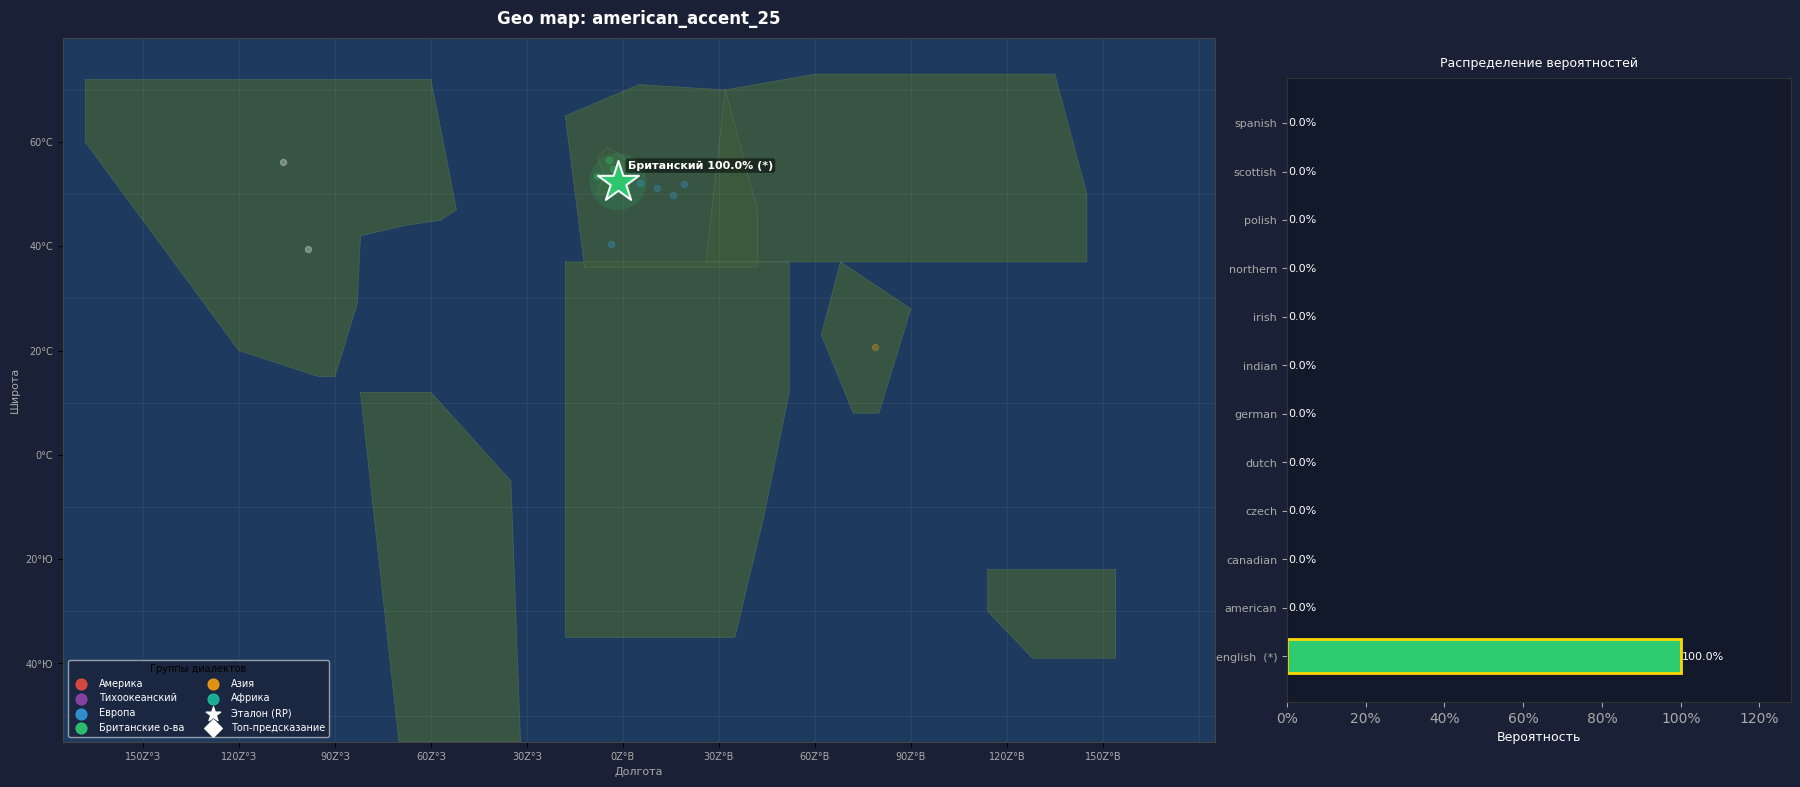

    Conformity tag: Близко к эталону

>>> AccentDataset/British_accent/british_accent_15.wav

  Прогноз региона:
   english              ###################          0.712  [ЭТАЛОН]
   american             ######                       0.243
   england                                           0.026
   dutch                                             0.019
   canadian                                          0.000
   czech                                             0.000
   german                                            0.000
   indian                                            0.000
   irish                                             0.000
   northern                                          0.000
   polish                                            0.000
   scottish                                          0.000
   spanish                                           0.000
  Top dialect  : english
  Region       : Британский RP [ЭТАЛОН]  (lat=52.4, lon=-1.5)
  Conformity   : 0.4972

09:30:08  INFO  Геокарта сохранена -> runs\dialect_v5\geomap_british_accent_15.png


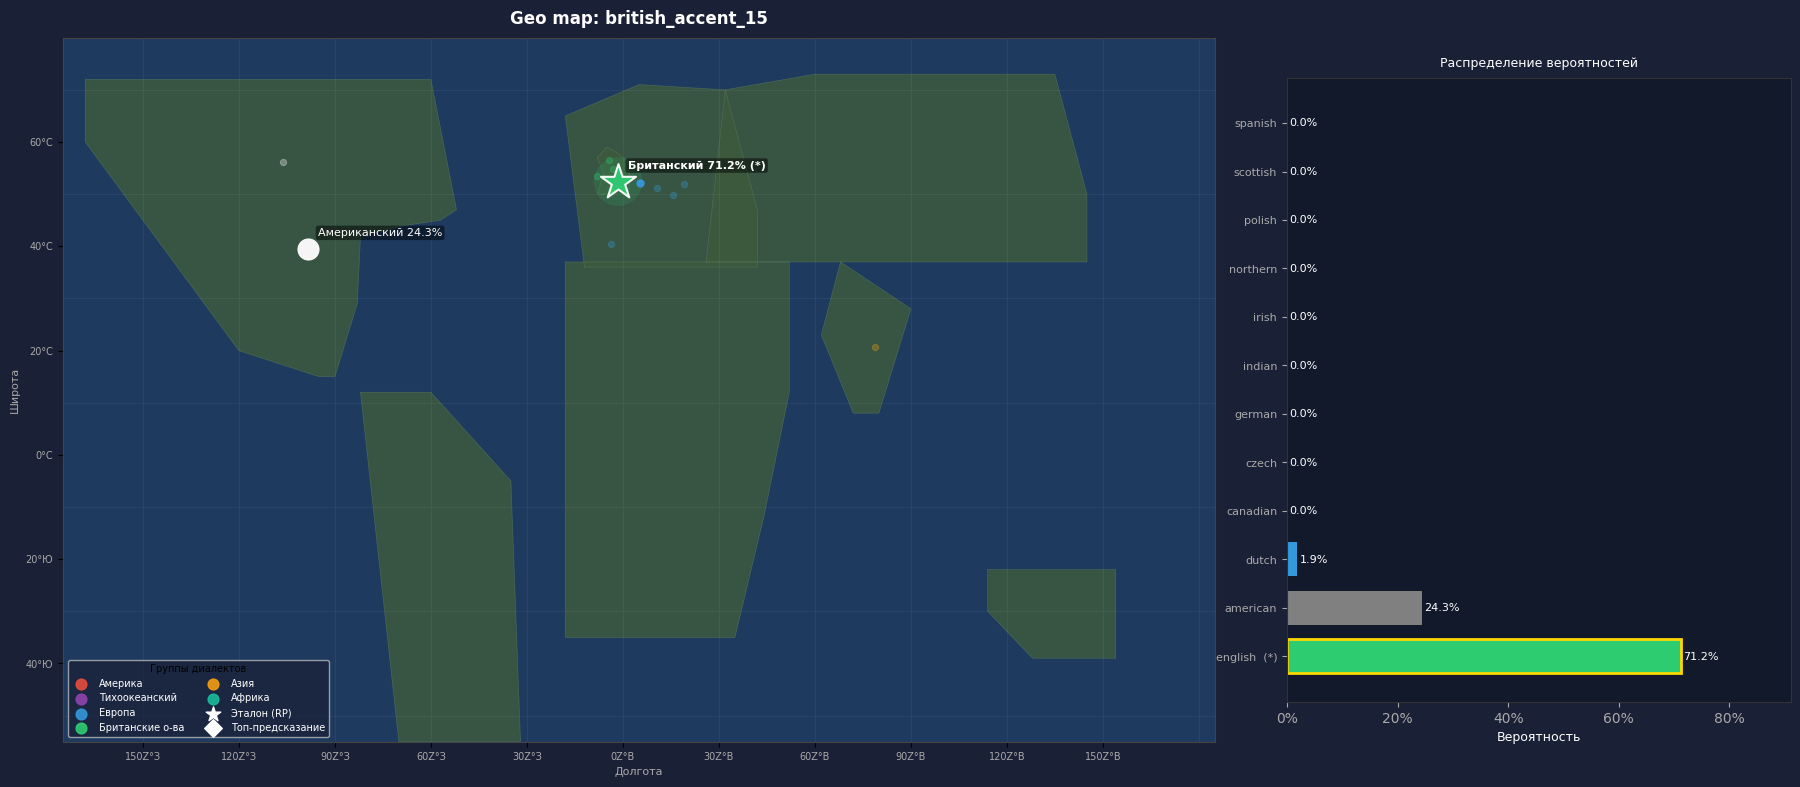

    Conformity tag: Значительное отклонение от RP

>>> AccentDataset/indian_accent/indian_accent_73.wav

  Прогноз региона:
   german               ############################ 1.000
   american                                          0.000
   canadian                                          0.000
   czech                                             0.000
   dutch                                             0.000
   england                                           0.000
   english                                           0.000  [ЭТАЛОН]
   indian                                            0.000
   irish                                             0.000
   northern                                          0.000
   polish                                            0.000
   scottish                                          0.000
   spanish                                           0.000
  Top dialect  : german
  Region       : Немецкий (EFL)  (lat=51.2, lon=10.5)
  Conformity   : 0.07

09:30:10  INFO  Геокарта сохранена -> runs\dialect_v5\geomap_indian_accent_73.png


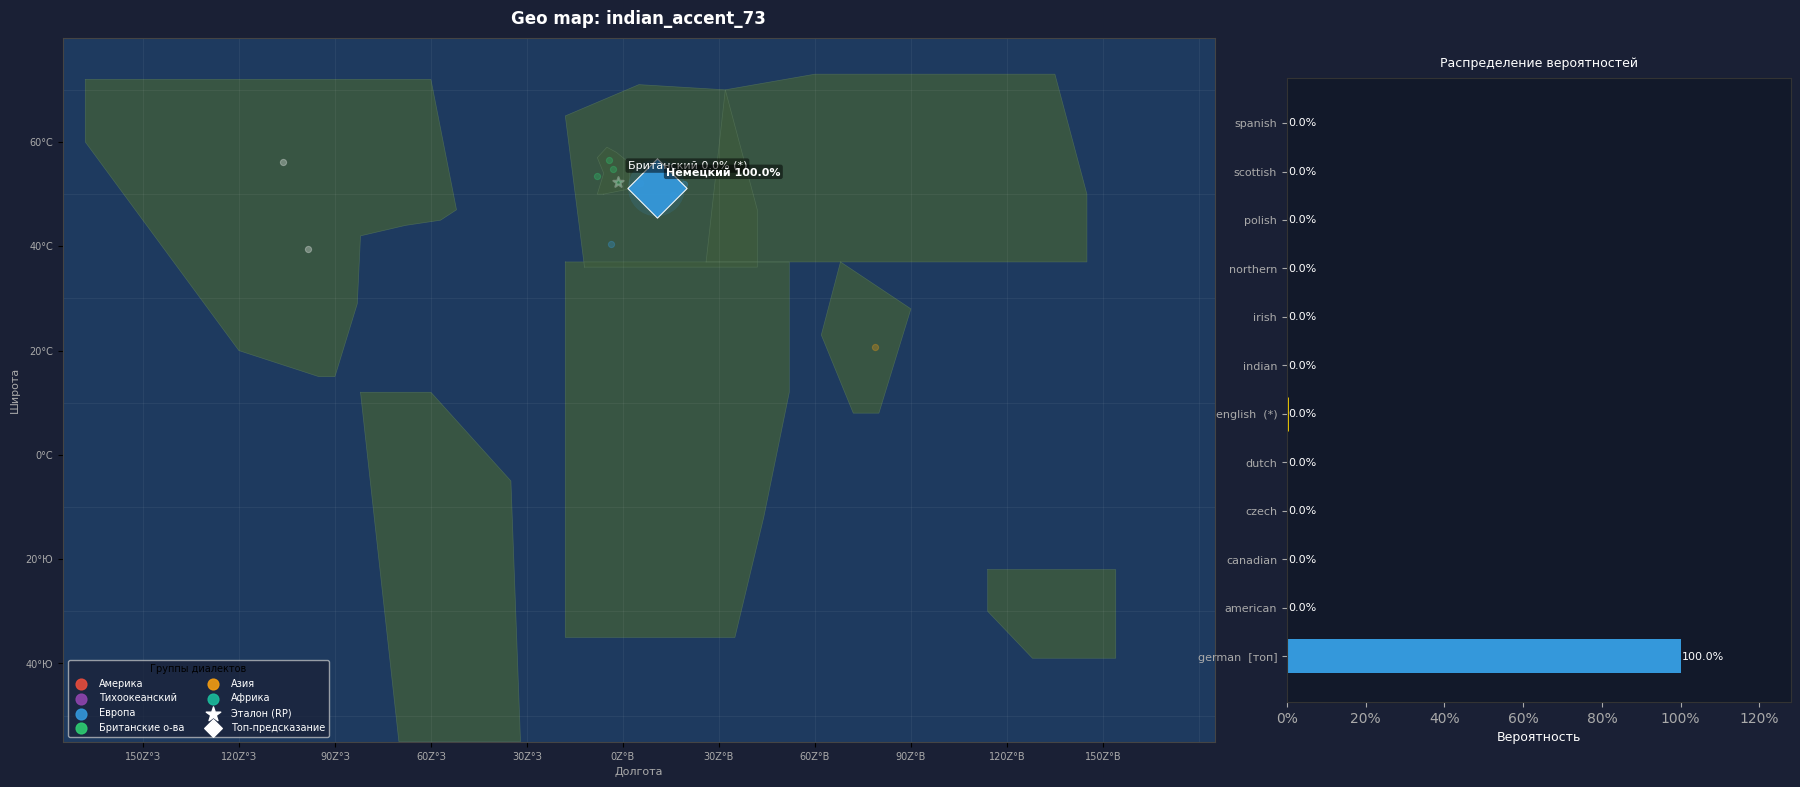

    Conformity tag: Значительное отклонение от RP


In [47]:
# 23. Full pipeline demo  (replace paths with real files)

test_files = [
    "AccentDataset/American_accent/american_accent_25.wav",
    "AccentDataset/British_accent/british_accent_15.wav",
    "AccentDataset/indian_accent/indian_accent_73.wav",
]

for test_path in test_files:
    print(f"\n>>> {test_path}")
    result = predictor_v2.predict_v2(test_path, show_map=True)
    print(f"    Conformity tag: {result['conformity_tag']}")

if not test_files:
    print("Add file paths to test_files list above.")
    print("  result = predictor_v2.predict_v2('path/to/audio.wav')")
